In [1]:
!pip install -q transformers librosa wandb scipy scikit-learn av face-alignment dlib yacs pydub gfpgan kornia safetensors
!git clone https://github.com/OpenTalker/SadTalker.git 2>/dev/null || true

!mkdir -p SadTalker/checkpoints
!wget -q -nc "https://github.com/OpenTalker/SadTalker/releases/download/v0.0.2/mapping_00109-model.pth.tar" -O SadTalker/checkpoints/mapping_00109-model.pth.tar
!wget -q -nc "https://github.com/OpenTalker/SadTalker/releases/download/v0.0.2/mapping_00229-model.pth.tar" -O SadTalker/checkpoints/mapping_00229-model.pth.tar
!wget -q -nc "https://github.com/OpenTalker/SadTalker/releases/download/v0.0.2-rc/SadTalker_V0.0.2_256.safetensors" -O SadTalker/checkpoints/SadTalker_V0.0.2_256.safetensors
!wget -q -nc "https://github.com/OpenTalker/SadTalker/releases/download/v0.0.2/BFM_Fitting.zip" -O /tmp/BFM_Fitting.zip
!unzip -qo /tmp/BFM_Fitting.zip -d SadTalker/checkpoints/

import safetensors
from pathlib import Path

ckpt = Path("SadTalker/checkpoints/SadTalker_V0.0.2_256.safetensors")
if ckpt.stat().st_size < 50_000_000:
    raise RuntimeError(f"Checkpoint seems too small ({ckpt.stat().st_size} bytes). Re-run this cell.")

try:
    with safetensors.safe_open(str(ckpt), framework="pt", device="cpu") as f:
        print(f"safetensor OK, tensors: {len(list(f.keys()))}")
except Exception as e:
    raise RuntimeError(f"Corrupted safetensor checkpoint: {e}")

!ls -lh SadTalker/checkpoints


safetensor OK, tensors: 1305
total 989M
drwxr-xr-x 2 root root 4.0K May  7 07:17 BFM_Fitting
drwxr-xr-x 3 root root 4.0K May  6 02:30 __MACOSX
-rw-r--r-- 1 root root 149M Apr  8  2023 mapping_00109-model.pth.tar
-rw-r--r-- 1 root root 149M Apr  8  2023 mapping_00229-model.pth.tar
-rw-r--r-- 1 root root 692M May 31  2023 SadTalker_V0.0.2_256.safetensors


In [2]:
import sys
sys.path.insert(0, "/content")
sys.path.insert(0, "/content/SadTalker")
sys.path.insert(0, "/content/SadTalker/src")

import gc
import json
import random
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import wandb
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import torchaudio
from emotion_utils import (
    DifferentiableVideoPreprocess,
    load_frozen_audio_encoder,
    load_frozen_video_encoder,
    extract_audio_embedding,
    extract_video_embedding,
)

from src.utils import audio as sadtalker_audio
from src.test_audio2coeff import Audio2Coeff
from src.utils.init_path import init_path

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
METADATA = "/content/processed_data/metadata.json"
SADTALKER_CKPT = Path("/content/SadTalker/checkpoints")
OUT_DIR = Path("/content/sadtalker_loss_ablation_4emo")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MEL_CACHE_DIR = OUT_DIR / "_mel_cache"
COEFF_CACHE_DIR = OUT_DIR / "_coeff_cache"
MEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
COEFF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE = {0, 1, 5, 7}
REMAP = {2: 0, 3: 1, 4: 2, 6: 3}
EMOTIONS = ["happy", "sad", "angry", "disgust"]


KL_TEMPERATURE = 2.0
LABEL_SMOOTHING = 0.1


class EmotionLossComposite(nn.Module):
    """Three-term composite — supports any subset of {CE, COS, KL} via weights.

    CE  : cross-entropy on TimeSformer-on-stub video logits vs labels.
    COS : 1 - cosine on cross-modal projections (audio_proj × video_proj).
    KL  : KL(softmax(audio_logits/T) || softmax(video_logits/T)) — distillation
          from frozen audio classifier to video logits.

    Same loss interface as 04a_wav2lip_loss_ablation.EmotionLossComposite for
    direct H1 ↔ H2 comparison of loss families."""

    def __init__(self, w_ce=0.0, w_cos=0.0, w_kl=0.0,
                 label_smoothing=LABEL_SMOOTHING, kl_temperature=KL_TEMPERATURE):
        super().__init__()
        self.w_ce = w_ce
        self.w_cos = w_cos
        self.w_kl = w_kl
        self.T = kl_temperature
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    @property
    def needs_video_logits(self):
        return self.w_ce > 0 or self.w_kl > 0

    @property
    def needs_audio_logits(self):
        return self.w_kl > 0

    @property
    def needs_projections(self):
        return self.w_cos > 0

    def forward(self, labels, video_logits=None, audio_logits=None,
                audio_proj=None, video_proj=None):
        device = labels.device
        total = torch.zeros((), device=device)
        parts = {"ce": 0.0, "cos": 0.0, "kl": 0.0}
        if self.w_ce > 0:
            ce = self.ce(video_logits, labels)
            total = total + self.w_ce * ce
            parts["ce"] = ce.item()
        if self.w_cos > 0:
            cos = (1.0 - F.cosine_similarity(audio_proj, video_proj, dim=-1)).mean()
            total = total + self.w_cos * cos
            parts["cos"] = cos.item()
        if self.w_kl > 0:
            log_p_v = F.log_softmax(video_logits / self.T, dim=-1)
            p_a = F.softmax(audio_logits / self.T, dim=-1)
            kl = F.kl_div(log_p_v, p_a, reduction="batchmean") * (self.T ** 2)
            total = total + self.w_kl * kl
            parts["kl"] = kl.item()
        return total, parts


# Best encoders from 02_train_encoders_4emotions.ipynb cell 12 RESULTS SUMMARY.
BEST_AUDIO_PATH = "/content/trained_encoders_4emotions/4emo-w2v2-er-lr3e5"
BEST_VIDEO_PATH = "/content/trained_encoders_4emotions/4emo-tsf-lr3e5-8f"
WAV2LIP_TO_ENCODER = [2, 3, 4, 6]  # used only if encoder head_labels != len(EMOTIONS)

SR = 16000
FPS = 25
SYNCNET_MEL_STEP = 16

print(f"Device: {DEVICE}")


Device: cuda


In [3]:
def crop_pad_audio(wav, audio_length):
    if len(wav) > audio_length:
        wav = wav[:audio_length]
    elif len(wav) < audio_length:
        wav = np.pad(wav, [0, audio_length - len(wav)], mode="constant", constant_values=0)
    return wav


def parse_audio_length(audio_length, sr=SR, fps=FPS):
    bit_per_frame = sr / fps
    num_frames = int(audio_length / bit_per_frame)
    audio_length = int(num_frames * bit_per_frame)
    return audio_length, num_frames


def build_indiv_mels(audio_path):
    wav = sadtalker_audio.load_wav(audio_path, SR)
    wav_length, _ = parse_audio_length(len(wav), SR, FPS)
    wav = crop_pad_audio(wav, wav_length)

    orig_mel = sadtalker_audio.melspectrogram(wav).T
    spec = orig_mel.copy()
    indiv_mels = []

    num_frames = int(wav_length / (SR / FPS))
    for i in range(num_frames):
        start_frame_num = i - 2
        start_idx = int(80.0 * (start_frame_num / float(FPS)))
        end_idx = start_idx + SYNCNET_MEL_STEP
        seq = np.arange(start_idx, end_idx)
        seq = np.clip(seq, 0, orig_mel.shape[0] - 1)
        m = spec[seq, :]
        indiv_mels.append(m.T.astype(np.float32))

    return np.asarray(indiv_mels, dtype=np.float32)  # (T, 80, 16)


class SadTalkerAudioDataset(Dataset):
    def __init__(self, metadata_path, split):
        with open(metadata_path) as f:
            data = json.load(f)
        self.samples = [
            s for s in data
            if s["split"] == split and s["emotion_idx"] not in EXCLUDE
        ]
        if len(self.samples) == 0:
            raise ValueError(f"No samples for split={split}")

    def __len__(self):
        return len(self.samples)

    def mel_cache_path(self, sample_id):
        return MEL_CACHE_DIR / f"{sample_id}.npy"

    def coeff_cache_path(self, sample_id):
        return COEFF_CACHE_DIR / f"{sample_id}_exp64.npy"

    def __getitem__(self, idx):
        s = self.samples[idx]
        sample_id = s["sample_id"]
        mel_path = self.mel_cache_path(sample_id)
        coeff_path = self.coeff_cache_path(sample_id)

        if not mel_path.exists():
            raise FileNotFoundError(f"Missing mel cache for {sample_id}. Run cache cell first.")
        if not coeff_path.exists():
            raise FileNotFoundError(f"Missing coeff cache for {sample_id}. Run cache cell first.")

        indiv_mels = np.load(mel_path)
        gt_exp = np.load(coeff_path)

        return {
            "sample_id": sample_id,
            "audio_path": s["audio_path"],
            "indiv_mels": torch.from_numpy(indiv_mels),
            "gt_exp": torch.from_numpy(gt_exp),
            "emotion": REMAP[s["emotion_idx"]],
        }


def collate_sadtalker(batch):
    return {
        "sample_id": [b["sample_id"] for b in batch],
        "audio_path": [b["audio_path"] for b in batch],
        "indiv_mels": [b["indiv_mels"] for b in batch],
        "gt_exp": [b["gt_exp"] for b in batch],
        "emotion": torch.tensor([b["emotion"] for b in batch], dtype=torch.long),
    }


train_ds = SadTalkerAudioDataset(METADATA, "train")
val_ds = SadTalkerAudioDataset(METADATA, "val")
test_ds = SadTalkerAudioDataset(METADATA, "test")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")


Train: 544, Val: 96, Test: 96


In [4]:
from src.face3d.models import networks
from src.utils.safetensor_helper import load_x_from_safetensor
import safetensors.torch


def load_face3drecon_model(ckpt_dir, device):
    ckpt_path = Path(ckpt_dir) / "SadTalker_V0.0.2_256.safetensors"
    net_recon = networks.define_net_recon(net_recon='resnet50', use_last_fc=False, init_path='').to(device)
    checkpoint = safetensors.torch.load_file(str(ckpt_path))
    net_recon.load_state_dict(load_x_from_safetensor(checkpoint, 'face_3drecon'))
    net_recon.eval()
    for p in net_recon.parameters():
        p.requires_grad = False
    return net_recon


@torch.no_grad()
def extract_gt_exp_coeff(frames_uint8, net_recon, device, batch_size=48):
    # frames_uint8: (T, H, W, 3), uint8
    x = torch.from_numpy(frames_uint8).permute(0, 3, 1, 2).float() / 255.0
    x = x.to(device)
    x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)

    out = []
    for i in range(0, x.shape[0], batch_size):
        coeff = net_recon(x[i:i+batch_size])   # (B, 257 or 256)
        exp = coeff[:, 80:144]                 # 64-d expression coeff
        out.append(exp.cpu())

    return torch.cat(out, dim=0).numpy().astype(np.float32)


def ensure_mel_cache(dataset, split_name):
    done = 0
    for s in tqdm(dataset.samples, desc=f"Mel cache [{split_name}]"):
        p = MEL_CACHE_DIR / f"{s['sample_id']}.npy"
        if p.exists():
            done += 1
            continue
        mel = build_indiv_mels(s["audio_path"])
        np.save(p, mel)
        done += 1
    print(f"{split_name}: mel cache ready for {done} samples")


def ensure_coeff_cache(dataset, split_name, net_recon):
    done = 0
    for s in tqdm(dataset.samples, desc=f"Coeff cache [{split_name}]"):
        p = COEFF_CACHE_DIR / f"{s['sample_id']}_exp64.npy"
        if p.exists():
            done += 1
            continue
        frames = np.load(s["frames_path"])  # (T, H, W, 3) uint8
        exp64 = extract_gt_exp_coeff(frames, net_recon, DEVICE)
        np.save(p, exp64)
        done += 1
    print(f"{split_name}: coeff cache ready for {done} samples")


def validate_cached_sample(sample, dataset, min_frames=2):
    sid = sample["sample_id"]
    mel_path = dataset.mel_cache_path(sid)
    coeff_path = dataset.coeff_cache_path(sid)

    try:
        mel = np.load(mel_path, mmap_mode="r")
        coeff = np.load(coeff_path, mmap_mode="r")
    except Exception as e:
        return False, f"load_error:{type(e).__name__}"

    if mel.ndim != 3 or mel.shape[1:] != (80, 16):
        return False, f"mel_shape:{tuple(mel.shape)}"
    if coeff.ndim != 2 or coeff.shape[1] != 64:
        return False, f"coeff_shape:{tuple(coeff.shape)}"
    if mel.shape[0] < min_frames:
        return False, f"mel_too_short:{mel.shape[0]}"
    if coeff.shape[0] < min_frames:
        return False, f"coeff_too_short:{coeff.shape[0]}"

    return True, ""


def filter_invalid_cached_samples(dataset, split_name, min_frames=2):
    from collections import Counter

    before = list(dataset.samples)
    kept = []
    dropped = []
    reason_counts = Counter()

    for s in tqdm(before, desc=f"Validate cache [{split_name}]"):
        ok, reason = validate_cached_sample(s, dataset, min_frames=min_frames)
        if ok:
            kept.append(s)
        else:
            dropped.append({
                "sample_id": s["sample_id"],
                "emotion": REMAP[s["emotion_idx"]],
                "reason": reason,
            })
            reason_counts[reason] += 1

    dataset.samples = kept

    emo_before = Counter(REMAP[s["emotion_idx"]] for s in before)
    emo_after = Counter(REMAP[s["emotion_idx"]] for s in kept)

    print(
        f"{split_name}: kept {len(kept)}/{len(before)} "
        f"({(len(kept)/max(1,len(before))):.2%}), dropped {len(dropped)}"
    )
    for e, name in enumerate(EMOTIONS):
        print(
            f"  {name:7s}: before={emo_before[e]:3d}, after={emo_after[e]:3d}, "
            f"dropped={emo_before[e]-emo_after[e]:3d}"
        )

    if dropped:
        print("  drop reasons (top 5):")
        for reason, cnt in reason_counts.most_common(5):
            print(f"    {reason}: {cnt}")
        preview = dropped[:10]
        print("  first dropped samples:")
        for r in preview:
            print(f"    {r['sample_id']} emo={EMOTIONS[r['emotion']]} reason={r['reason']}")

    return dropped


net_recon = load_face3drecon_model(SADTALKER_CKPT, DEVICE)
ensure_mel_cache(train_ds, "train")
ensure_mel_cache(val_ds, "val")
ensure_mel_cache(test_ds, "test")
ensure_coeff_cache(train_ds, "train", net_recon)
ensure_coeff_cache(val_ds, "val", net_recon)
ensure_coeff_cache(test_ds, "test", net_recon)
del net_recon
torch.cuda.empty_cache()

# Filter invalid cached samples once, so training/eval loops do not silently skip.
train_dropped = filter_invalid_cached_samples(train_ds, "train", min_frames=2)
val_dropped = filter_invalid_cached_samples(val_ds, "val", min_frames=2)
test_dropped = filter_invalid_cached_samples(test_ds, "test", min_frames=2)
print(f"Filtered dataset sizes -> Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")


def load_sadtalker_netg(ckpt_dir, device):
    sadtalker_paths = init_path(
        str(ckpt_dir),
        "/content/SadTalker/src/config",
        "256",
        False,
        "crop",
    )
    audio2coeff = Audio2Coeff(sadtalker_paths, device)
    netG = audio2coeff.audio2exp_model.netG.to(device)
    return netG


def set_trainable_layers(netG, mode="upper_audio"):
    for p in netG.parameters():
        p.requires_grad = False

    if mode == "mapping1":
        for p in netG.mapping1.parameters():
            p.requires_grad = True
    elif mode == "upper_audio":
        # Unfreeze mapping1 + last 4 conv blocks of audio encoder.
        for p in netG.mapping1.parameters():
            p.requires_grad = True
        for block in list(netG.audio_encoder.children())[-4:]:
            for p in block.parameters():
                p.requires_grad = True
    elif mode == "all":
        for p in netG.parameters():
            p.requires_grad = True
    else:
        raise ValueError(f"Unknown unfreeze mode: {mode}")


def count_params(module):
    total = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return total, trainable


def make_ref_coeff_70(gt_exp):
    # gt_exp: (T, 64)
    ref = torch.zeros((1, 70), dtype=torch.float32, device=gt_exp.device)
    ref[0, :64] = gt_exp[0]
    return ref


def make_batch_dict(indiv_mels, ref_coeff_70, device):
    # indiv_mels: (T, 80, 16)
    T = indiv_mels.shape[0]
    ref = ref_coeff_70.repeat(T, 1).unsqueeze(0).to(device)  # (1, T, 70)
    ratio = torch.zeros((1, T), dtype=torch.float32, device=device)
    return {
        "indiv_mels": indiv_mels.unsqueeze(0).unsqueeze(2).to(device),  # (1, T, 1, 80, 16)
        "ref": ref,
        "ratio_gt": ratio,
    }


def predict_exp_coeff(netG, batch_dict):
    mel_input = batch_dict["indiv_mels"]
    ref = batch_dict["ref"][:, :, :64]
    ratio = batch_dict["ratio_gt"]

    preds = []
    for i in range(0, mel_input.shape[1], 10):
        cur_mel = mel_input[:, i:i+10]
        cur_ref = ref[:, i:i+10]
        cur_ratio = ratio[:, i:i+10]
        audiox = cur_mel.reshape(-1, 1, 80, 16)
        preds.append(netG(audiox, cur_ref, cur_ratio))

    return torch.cat(preds, dim=1)  # (1, T, 64)


net_preview = load_sadtalker_netg(SADTALKER_CKPT, DEVICE)
for mode in ["mapping1", "upper_audio", "all"]:
    set_trainable_layers(net_preview, mode)
    total, trainable = count_params(net_preview)
    print(f"mode={mode:11s} trainable={trainable/1e6:.3f}M / total={total/1e6:.3f}M")
del net_preview

audio_enc, audio_proc = load_frozen_audio_encoder(BEST_AUDIO_PATH, DEVICE)
video_enc = load_frozen_video_encoder(BEST_VIDEO_PATH, DEVICE)
video_preprocess = DifferentiableVideoPreprocess(224).to(DEVICE)
VIDEO_ENC_FRAMES = int(getattr(video_enc.config, "num_frames", 8))
AUDIO_DIM = audio_enc.config.hidden_size
VIDEO_DIM = video_enc.config.hidden_size
AUDIO_HEAD_LABELS = int(getattr(audio_enc.config, "num_labels", len(EMOTIONS)))
VIDEO_HEAD_LABELS = int(getattr(video_enc.config, "num_labels", len(EMOTIONS)))
PROJ_DIM = 256  # for cos variant's audio_proj / video_proj
# emo_loss_fn is rebuilt per config in cell 6 (each ablation has its own w_ce/w_cos/w_kl).
print(
    f"Frozen encoders (02 4-emo): T={VIDEO_ENC_FRAMES}, audio_dim={AUDIO_DIM}, "
    f"video_dim={VIDEO_DIM}, audio_head={AUDIO_HEAD_LABELS}, video_head={VIDEO_HEAD_LABELS}"
)
torch.cuda.empty_cache()



Mel cache [train]: 100%|██████████| 544/544 [00:00<00:00, 114716.01it/s]


train: mel cache ready for 544 samples


Mel cache [val]: 100%|██████████| 96/96 [00:00<00:00, 85780.40it/s]


val: mel cache ready for 96 samples


Mel cache [test]: 100%|██████████| 96/96 [00:00<00:00, 95415.45it/s]


...

train: kept 544/544 (100.00%), dropped 0
  happy  : before=136, after=136, dropped=  0
  sad    : before=136, after=136, dropped=  0
  angry  : before=136, after=136, dropped=  0
  disgust: before=136, after=136, dropped=  0


Validate cache [val]: 100%|██████████| 96/96 [00:00<00:00, 3753.64it/s]


val: kept 96/96 (100.00%), dropped 0
  happy  : before= 24, after= 24, dropped=  0
  sad    : before= 24, after= 24, dropped=  0
  angry  : before= 24, after= 24, dropped=  0
  disgust: before= 24, after= 24, dropped=  0


Validate cache [test]: 100%|██████████| 96/96 [00:00<00:00, 3687.33it/s]


test: kept 96/96 (100.00%), dropped 0
  happy  : before= 24, after= 24, dropped=  0
  sad    : before= 24, after= 24, dropped=  0
  angry  : before= 24, after= 24, dropped=  0
  disgust: before= 24, after= 24, dropped=  0
Filtered dataset sizes -> Train: 544, Val: 96, Test: 96
using safetensor as default
mode=mapping1    trainable=0.037M / total=2.850M
mode=upper_audio trainable=2.368M / total=2.850M
mode=all         trainable=2.850M / total=2.850M
Frozen encoders (02 4-emo): T=8, audio_dim=768, video_dim=768, audio_head=4, video_head=4


In [5]:
wandb.login()

# 5-way ablation over loss families (mirrors 04a_wav2lip_loss_ablation.CONFIGS).
# Each row picks ONE loss family at a fixed weight — same weights as 04a so H1↔H2
# is a head-to-head comparison of loss design, not weight tuning.
ABLATION_CONFIGS = [
    {"name": "abl-baseline", "w_ce": 0.00, "w_cos": 0.0, "w_kl": 0.0},
    {"name": "abl-cos-only", "w_ce": 0.00, "w_cos": 0.2, "w_kl": 0.0},
    {"name": "abl-ce-only",  "w_ce": 0.05, "w_cos": 0.0, "w_kl": 0.0},
    {"name": "abl-ce-cos",   "w_ce": 0.05, "w_cos": 0.2, "w_kl": 0.0},
    {"name": "abl-ce-kl",    "w_ce": 0.05, "w_cos": 0.0, "w_kl": 0.1},
]
CONFIGS = ABLATION_CONFIGS  # alias used downstream (cell 6, 7, ...)
# Compatibility shims for downstream code that reads cfg["scale"] etc.
for _c in CONFIGS:
    _c["scale"] = 1.0 if (_c["w_ce"] + _c["w_cos"] + _c["w_kl"] > 0) else 0.0  # gate flag

UNFREEZE_MODE = "upper_audio"  # mapping1 | upper_audio | all
W_COEFF_EXP = 2.0               # original SadTalker coeff-exp weight

# Save checkpoint by emotion F1 to optimize the primary target metric.
# Options: "f1" | "emo_accuracy" | "emo_macro_acc" | "val_total"
CHECKPOINT_BY = "f1"

# Per-class CE weights for emo_head (order: happy, sad, angry, disgust)
EMO_CLASS_WEIGHTS = [1.0, 1.6, 1.0, 1.0]  # boost sad (encoder ceiling 0.72 vs others 0.91+)

# Limit temporal window to reduce train-time memory/runtime failures on long clips.
# At 25 FPS: 120 ~= 4.8s.
MAX_FRAMES_TRAIN = 120
MAX_FRAMES_EVAL = 120
RANDOM_WINDOW_TRAIN = True

# Optional quick-mode cap for validation samples (None = full val set).
VAL_MAX_SAMPLES = None

# Raise immediately on per-sample runtime errors (use True for strict debugging).
FAIL_ON_SAMPLE_ERROR = False
ERROR_EXAMPLE_LIMIT = 5

# Warn if too many samples are skipped during per-sample processing.
MIN_VALID_RATIO_WARN = 0.98

if UNFREEZE_MODE == "all":
    LR = 2e-5
    BATCH_SIZE = 4
elif UNFREEZE_MODE == "upper_audio":
    LR = 3e-5
    BATCH_SIZE = 4
else:
    LR = 8e-5
    BATCH_SIZE = 6

EPOCHS = 60
PATIENCE = 12
WARMUP_EPOCHS = 5
NUM_WORKERS = 0

# Emotion head is newly initialized; use higher LR than netG.
LR_EMO_HEAD = 5e-4
WEIGHT_DECAY = 1e-4

print(
    f"Unfreeze mode: {UNFREEZE_MODE}, LR={LR}, BATCH_SIZE={BATCH_SIZE}, "
    f"W_COEFF_EXP={W_COEFF_EXP}, CHECKPOINT_BY={CHECKPOINT_BY}, "
    f"EMO_CLASS_WEIGHTS={EMO_CLASS_WEIGHTS}, "
    f"MAX_FRAMES(train/eval)={MAX_FRAMES_TRAIN}/{MAX_FRAMES_EVAL}, "
    f"VAL_MAX_SAMPLES={VAL_MAX_SAMPLES}, "
    f"LR_EMO_HEAD={LR_EMO_HEAD}, WEIGHT_DECAY={WEIGHT_DECAY}, "
    f"EPOCHS={EPOCHS}, PATIENCE={PATIENCE}, WARMUP_EPOCHS={WARMUP_EPOCHS}"
)


wandb: Currently logged in as: katrinpochtar to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Unfreeze mode: upper_audio, LR=3e-05, BATCH_SIZE=4, W_COEFF_EXP=2.0, CHECKPOINT_BY=f1, EMO_CLASS_WEIGHTS=[1.0, 1.6, 1.0, 1.0], MAX_FRAMES(train/eval)=120/120, VAL_MAX_SAMPLES=None, LR_EMO_HEAD=0.0005, WEIGHT_DECAY=0.0001, EPOCHS=60, PATIENCE=12, WARMUP_EPOCHS=5


In [6]:
"""Fine-tuning loss (SadTalker netG).

L = W_COEFF_EXP * L1(pred_coeff, gt_coeff) + (BASE_W_CE * scale * CE(v_logits, y)
    + BASE_W_KL * scale * T**2 * KL(softmax(a_logits/T) || softmax(v_logits/T)))
    + CE(emo_head(feats), y)

- Coeff: L1 on predicted vs GT 64-d expression over the (possibly cropped) time window.
- Cross-modal term (mirrors 06_finetune_wav2lip.ipynb CE+KL composite):
    (a) CE on frozen TimeSformer logits applied to the PredCoeffToVideoStub frame
        (MLP → 32² → upsample 224² → repeat VIDEO_ENC_FRAMES). Gradient flows back to netG.
    (b) KL distillation from frozen 4-emo audio classifier (Wav2Vec2-er) to TSF-on-stub
        logits, T=2.0. Audio is no_grad. Same shared-label-space setup as in 06.
- emo_head CE gradients flow back to netG, providing direct emotion supervision to the generator.
- emo_accuracy / by_emotion use the frozen TimeSformer classifier on the stub tensor (3-class checkpoints).
- Validation drives early stopping / checkpoint; test metrics are computed per config after training.
"""


def adapt_frames(frames, target_t):
    """Resample (B, T, C, H, W) to (B, target_t, C, H, W) via uniform index sampling."""
    B, T, C, H, W = frames.shape
    if T == target_t:
        return frames
    idx = torch.linspace(0, T - 1, target_t, device=frames.device).long()
    return frames[:, idx]


def classify_gen_video(gen_frames, batch_emotions):
    """Frozen TimeSformer classifier logits on stub RGB (monitoring; not the cosine loss)."""
    gen_video = adapt_frames(gen_frames, VIDEO_ENC_FRAMES)
    pv = video_preprocess(gen_video)
    logits = video_enc(pixel_values=pv).logits
    n_lab = int(getattr(video_enc.config, "num_labels", logits.shape[-1]))
    if n_lab == len(EMOTIONS):
        logits_3 = logits
    else:
        logits_3 = logits[:, WAV2LIP_TO_ENCODER]
    labels_3 = batch_emotions.to(DEVICE)
    return logits_3, labels_3


@torch.no_grad()
def compute_audio_logits(batch_audio):
    """Frozen audio classifier — KL reference distribution. Single forward pass per call."""
    sr = getattr(audio_proc, "sampling_rate", SR)
    wavs = [a.numpy() for a in batch_audio]
    enc = audio_proc(wavs, sampling_rate=sr, return_tensors="pt",
                     padding="max_length", truncation=True, max_length=int(3.0 * SR))
    kwargs = {"input_values": enc["input_values"].to(DEVICE)}
    if "attention_mask" in enc:
        kwargs["attention_mask"] = enc["attention_mask"].to(DEVICE)
    logits = audio_enc(**kwargs).logits
    if AUDIO_HEAD_LABELS == len(EMOTIONS):
        return logits
    return logits[:, WAV2LIP_TO_ENCODER]


def compute_emo_term(gen_video, batch_audio, label, audio_proj=None, video_proj=None):
    """Composite loss term for one sample. Dispatches by emo_loss_fn weights.

    label: (1,) long tensor on device.
    audio_proj/video_proj: only required when emo_loss_fn.w_cos > 0.
    Returns scalar tensor (already weighted by w_ce/w_cos/w_kl)."""
    v_logits = a_logits = a_p = v_p = None
    if emo_loss_fn.needs_video_logits:
        v_logits, _ = classify_gen_video(gen_video, label)              # (1, NUM_EMO)
    if emo_loss_fn.needs_audio_logits:
        a_logits = compute_audio_logits(batch_audio)                    # (1, NUM_EMO)
    if emo_loss_fn.needs_projections:
        gen_adapt = adapt_frames(gen_video, VIDEO_ENC_FRAMES)
        with torch.no_grad():
            a_raw = extract_audio_embedding(audio_enc, audio_proc, batch_audio, device=DEVICE)
        a_p = audio_proj(a_raw)
        v_raw = extract_video_embedding(video_enc, video_preprocess, gen_adapt, device=DEVICE)
        v_p = video_proj(v_raw)
    label_t = label.to(DEVICE).long().view(1)
    loss, _parts = emo_loss_fn(label_t, video_logits=v_logits, audio_logits=a_logits,
                                audio_proj=a_p, video_proj=v_p)
    return loss


class PredCoeffToVideoStub(nn.Module):
    """Maps temporal-mean predicted expression (64,) to a single RGB frame for the video encoder."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 3 * 32 * 32),
        )

    def forward(self, coeff_mean):
        x = self.net(coeff_mean).view(3, 32, 32)
        x = F.interpolate(x.unsqueeze(0), size=(224, 224), mode="bilinear", align_corners=False).squeeze(0)
        return x.clamp(0.0, 1.0)


def stub_video_batch(pred_t, pred_video_stub):
    """pred_t: (T, 64) -> (1, VIDEO_ENC_FRAMES, 3, 224, 224)."""
    img = pred_video_stub(pred_t.mean(dim=0))
    return img.unsqueeze(0).unsqueeze(0).expand(1, VIDEO_ENC_FRAMES, -1, -1, -1)


def load_mono_wav_tensor(path):
    wav, _ = torchaudio.load(path)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    return wav.squeeze(0).float()


def build_emo_head():
    return nn.Sequential(
        nn.Linear(128, 128),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(128, len(EMOTIONS)),
    ).to(DEVICE)


def make_emo_features(pred_t):
    mean = pred_t.mean(dim=0)
    std = pred_t.std(dim=0, unbiased=False)
    return torch.cat([mean, std], dim=0)


def choose_window(total_t, max_frames=None, random_window=False):
    if total_t < 2:
        return None, None

    if max_frames is not None and max_frames > 1 and total_t > max_frames:
        if random_window:
            start = int(torch.randint(0, total_t - max_frames + 1, (1,)).item())
        else:
            start = int((total_t - max_frames) // 2)
        end = start + max_frames
        return start, end

    return 0, total_t


def slice_inputs_for_forward(indiv_mels, gt_exp, max_frames=None, random_window=False):
    total_t = min(int(indiv_mels.shape[0]), int(gt_exp.shape[0]))
    start, end = choose_window(total_t, max_frames=max_frames, random_window=random_window)
    if start is None:
        return None, None
    return indiv_mels[start:end], gt_exp[start:end]


def trim_pair(pred, gt_exp):
    T = min(pred.shape[0], gt_exp.shape[0])
    if T < 2:
        return None, None
    return pred[:T], gt_exp[:T]


def get_emo_ce_weight():
    if EMO_CLASS_WEIGHTS is None:
        return None
    w = torch.tensor(EMO_CLASS_WEIGHTS, dtype=torch.float32, device=DEVICE)
    if w.numel() != len(EMOTIONS):
        raise ValueError(
            f"EMO_CLASS_WEIGHTS must have {len(EMOTIONS)} values, got {w.numel()}"
        )
    return w


def make_error_key(exc):
    msg = str(exc).splitlines()[0] if str(exc) else "<no message>"
    return f"{type(exc).__name__}: {msg[:120]}"


def format_error_report(error_counts, top_k=3):
    if not error_counts:
        return ""
    items = sorted(error_counts.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return " | ".join([f"{k} x{v}" for k, v in items])


def build_model_bundle(unfreeze_mode, need_projections=False):
    """Returns (netG, emo_head, pred_video_stub, audio_proj_or_None, video_proj_or_None,
    total, trainable). Projections built only if cos term is active."""
    netG = load_sadtalker_netg(SADTALKER_CKPT, DEVICE)
    set_trainable_layers(netG, unfreeze_mode)
    emo_head = build_emo_head()
    pred_video_stub = PredCoeffToVideoStub().to(DEVICE)
    if need_projections:
        audio_proj = nn.Linear(AUDIO_DIM, PROJ_DIM).to(DEVICE)
        video_proj = nn.Linear(VIDEO_DIM, PROJ_DIM).to(DEVICE)
    else:
        audio_proj = video_proj = None

    total = sum(p.numel() for p in netG.parameters())
    trainable = sum(p.numel() for p in netG.parameters() if p.requires_grad)
    return netG, emo_head, pred_video_stub, audio_proj, video_proj, total, trainable


def train_one_epoch(
    netG, emo_head, pred_video_stub, audio_proj, video_proj,
    loader, optimizer, scaler, weight_emo, w_coeff_exp,
):
    netG.train()
    emo_head.train()
    pred_video_stub.train()
    if audio_proj is not None: audio_proj.train()
    if video_proj is not None: video_proj.train()

    total_coeff, total_emo, total_loss = 0.0, 0.0, 0.0
    n_steps = 0

    total_items = 0
    valid_items = 0
    skipped_shape = 0
    skipped_error = 0
    error_counts = {}
    error_examples = []
    error_sample_ids = []

    emo_ce_weight = get_emo_ce_weight()

    for batch in tqdm(loader, leave=False):
        labels = batch["emotion"].to(DEVICE)
        total_items += len(batch["indiv_mels"])

        optimizer.zero_grad(set_to_none=True)

        coeff_terms = []
        cm_terms = []
        feats = []
        valid_labels = []

        with autocast("cuda", enabled=DEVICE == "cuda"):
            for i, indiv_mels in enumerate(batch["indiv_mels"]):
                sid = batch["sample_id"][i]
                try:
                    gt_exp = batch["gt_exp"][i].float().to(DEVICE)
                    if gt_exp.ndim != 2 or gt_exp.shape[1] != 64 or gt_exp.shape[0] < 2:
                        skipped_shape += 1
                        continue

                    indiv_clip, gt_clip = slice_inputs_for_forward(
                        indiv_mels.float(),
                        gt_exp,
                        max_frames=MAX_FRAMES_TRAIN,
                        random_window=RANDOM_WINDOW_TRAIN,
                    )
                    if indiv_clip is None:
                        skipped_shape += 1
                        continue

                    ref_coeff_70 = make_ref_coeff_70(gt_clip)
                    bd = make_batch_dict(indiv_clip, ref_coeff_70, DEVICE)
                    pred = predict_exp_coeff(netG, bd).squeeze(0)

                    pred_t, gt_t = trim_pair(pred, gt_clip)
                    if pred_t is None:
                        skipped_shape += 1
                        continue

                    coeff_terms.append(F.l1_loss(pred_t, gt_t))
                    feats.append(make_emo_features(pred_t))
                    valid_labels.append(labels[i])
                    valid_items += 1

                    if weight_emo > 0:
                        gen_v = stub_video_batch(pred_t, pred_video_stub)
                        wav_cpu = load_mono_wav_tensor(batch["audio_path"][i])
                        cm_terms.append(
                            compute_emo_term(gen_v, [wav_cpu], labels[i:i+1], audio_proj, video_proj)
                        )
                except Exception as exc:
                    skipped_error += 1
                    key = make_error_key(exc)
                    error_counts[key] = error_counts.get(key, 0) + 1
                    if len(error_examples) < ERROR_EXAMPLE_LIMIT:
                        error_examples.append(f"{sid}: {key}")
                    error_sample_ids.append(sid)
                    if FAIL_ON_SAMPLE_ERROR:
                        raise
                    continue

            if not coeff_terms:
                continue

            coeff_exp = torch.stack(coeff_terms).mean()
            coeff_loss = w_coeff_exp * coeff_exp

            feats = torch.stack(feats, dim=0)
            valid_labels = torch.stack(valid_labels)

            cls_loss = F.cross_entropy(emo_head(feats), valid_labels, weight=emo_ce_weight)

            if weight_emo > 0 and cm_terms:
                cm_batch = torch.stack(cm_terms).mean()
            else:
                cm_batch = torch.tensor(0.0, device=DEVICE)

            report_loss = coeff_loss + cm_batch  # composite already weighted by emo_loss_fn.w_ce/w_kl
            loss = report_loss + cls_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        train_params = (
            [p for p in netG.parameters() if p.requires_grad]
            + list(emo_head.parameters())
            + list(pred_video_stub.parameters())
        )
        nn.utils.clip_grad_norm_(train_params, 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_coeff += coeff_exp.item()
        total_emo += cm_batch.item()
        total_loss += report_loss.item()
        n_steps += 1

    skipped_items = max(0, total_items - valid_items)
    valid_ratio = (valid_items / total_items) if total_items > 0 else 0.0
    error_report = format_error_report(error_counts)
    error_sample_ids = list(dict.fromkeys(error_sample_ids))

    if n_steps == 0:
        return {
            "recon": float("inf"),
            "emotion": float("inf"),
            "total": float("inf"),
            "valid_ratio": valid_ratio,
            "total_items": total_items,
            "valid_items": valid_items,
            "skipped_items": skipped_items,
            "skipped_shape": skipped_shape,
            "skipped_error": skipped_error,
            "error_report": error_report,
            "error_examples": error_examples,
            "error_sample_ids": error_sample_ids,
        }

    return {
        "recon": total_coeff / n_steps,
        "emotion": total_emo / n_steps,
        "total": total_loss / n_steps,
        "valid_ratio": valid_ratio,
        "total_items": total_items,
        "valid_items": valid_items,
        "skipped_items": skipped_items,
        "skipped_shape": skipped_shape,
        "skipped_error": skipped_error,
        "error_report": error_report,
        "error_examples": error_examples,
        "error_sample_ids": error_sample_ids,
    }


@torch.no_grad()
def evaluate(netG, emo_head, pred_video_stub, audio_proj, video_proj, loader, weight_emo, w_coeff_exp):
    netG.eval()
    emo_head.eval()
    pred_video_stub.eval()
    if audio_proj is not None: audio_proj.eval()
    if video_proj is not None: video_proj.eval()

    total_coeff, total_emo, total_loss = 0.0, 0.0, 0.0
    correct, total_samples = 0, 0
    n_steps = 0

    total_items = 0
    valid_items = 0
    skipped_shape = 0
    skipped_error = 0
    error_counts = {}
    error_examples = []
    error_sample_ids = []

    correct_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    total_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, leave=False):
        labels = batch["emotion"].to(DEVICE)

        coeff_terms = []
        cm_terms = []

        with autocast("cuda", enabled=DEVICE == "cuda"):
            for i, indiv_mels in enumerate(batch["indiv_mels"]):
                if VAL_MAX_SAMPLES is not None and total_items >= VAL_MAX_SAMPLES:
                    break

                sid = batch["sample_id"][i]
                total_items += 1

                try:
                    gt_exp = batch["gt_exp"][i].float().to(DEVICE)
                    if gt_exp.ndim != 2 or gt_exp.shape[1] != 64 or gt_exp.shape[0] < 2:
                        skipped_shape += 1
                        continue

                    indiv_clip, gt_clip = slice_inputs_for_forward(
                        indiv_mels.float(),
                        gt_exp,
                        max_frames=MAX_FRAMES_EVAL,
                        random_window=False,
                    )
                    if indiv_clip is None:
                        skipped_shape += 1
                        continue

                    ref_coeff_70 = make_ref_coeff_70(gt_clip)
                    bd = make_batch_dict(indiv_clip, ref_coeff_70, DEVICE)
                    pred = predict_exp_coeff(netG, bd).squeeze(0)

                    pred_t, gt_t = trim_pair(pred, gt_clip)
                    if pred_t is None:
                        skipped_shape += 1
                        continue

                    coeff_terms.append(F.l1_loss(pred_t, gt_t))
                    valid_items += 1

                    feats = make_emo_features(pred_t)
                    logits = emo_head(feats.unsqueeze(0))
                    lab = labels[i].view(1).to(DEVICE)
                    pr = logits.argmax(dim=1)
                    correct += (pr == lab).sum().item()
                    total_samples += 1
                    e = int(labels[i].item())
                    p = int(pr.item())
                    all_labels.append(e)
                    all_preds.append(p)
                    total_by_emo[e] += 1
                    if p == e:
                        correct_by_emo[e] += 1

                    if weight_emo > 0:
                        gen_v = stub_video_batch(pred_t, pred_video_stub)
                        wav_cpu = load_mono_wav_tensor(batch["audio_path"][i])
                        cm_terms.append(
                            compute_emo_term(gen_v, [wav_cpu], labels[i:i+1], audio_proj, video_proj)
                        )
                except Exception as exc:
                    skipped_error += 1
                    key = make_error_key(exc)
                    error_counts[key] = error_counts.get(key, 0) + 1
                    if len(error_examples) < ERROR_EXAMPLE_LIMIT:
                        error_examples.append(f"{sid}: {key}")
                    error_sample_ids.append(sid)
                    if FAIL_ON_SAMPLE_ERROR:
                        raise
                    continue

            if not coeff_terms:
                if VAL_MAX_SAMPLES is not None and total_items >= VAL_MAX_SAMPLES:
                    break
                continue

            coeff_exp = torch.stack(coeff_terms).mean()
            coeff_loss = w_coeff_exp * coeff_exp

            if weight_emo > 0 and cm_terms:
                cm_batch = torch.stack(cm_terms).mean()
            else:
                cm_batch = torch.tensor(0.0, device=DEVICE)

            report_loss = coeff_loss + cm_batch  # composite already weighted by emo_loss_fn.w_ce/w_kl

        total_coeff += coeff_exp.item()
        total_emo += cm_batch.item()
        total_loss += report_loss.item()
        n_steps += 1

        if VAL_MAX_SAMPLES is not None and total_items >= VAL_MAX_SAMPLES:
            break

    skipped_items = max(0, total_items - valid_items)
    valid_ratio = (valid_items / total_items) if total_items > 0 else 0.0
    error_report = format_error_report(error_counts)
    error_sample_ids = list(dict.fromkeys(error_sample_ids))

    by_emotion = {
        e: (correct_by_emo[e] / total_by_emo[e]) if total_by_emo[e] > 0 else 0.0
        for e in range(len(EMOTIONS))
    }
    emo_macro_acc = float(np.mean(list(by_emotion.values()))) if by_emotion else 0.0
    mean_cosine_sim = 0.0  # composite loss has no cosine term; kept for downstream API compatibility

    per_emotion_prf = {}
    emo_f1 = 0.0
    if all_preds:
        from sklearn.metrics import precision_recall_fscore_support, f1_score
        prec, rec, f1, sup = precision_recall_fscore_support(
            all_labels, all_preds, labels=list(range(len(EMOTIONS))), zero_division=0,
        )
        emo_f1 = float(f1_score(all_labels, all_preds, labels=list(range(len(EMOTIONS))), average="macro", zero_division=0))
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": float(prec[e]), "recall": float(rec[e]), "f1": float(f1[e]), "support": int(sup[e])}
    else:
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": 0.0, "recall": 0.0, "f1": 0.0, "support": 0}

    _empty_prf = {e: {"precision": 0.0, "recall": 0.0, "f1": 0.0, "support": 0} for e in range(len(EMOTIONS))}

    if n_steps == 0:
        return {
            "recon": float("inf"),
            "emotion": float("inf"),
            "total": float("inf"),
            "emo_accuracy": 0.0,
            "emo_macro_acc": 0.0,
            "f1": 0.0,
            "by_emotion": {e: 0.0 for e in range(len(EMOTIONS))},
            "per_emotion_prf": _empty_prf,
            "mean_cosine_sim": 0.0,
            "valid_ratio": valid_ratio,
            "total_items": total_items,
            "valid_items": valid_items,
            "skipped_items": skipped_items,
            "skipped_shape": skipped_shape,
            "skipped_error": skipped_error,
            "error_report": error_report,
            "error_examples": error_examples,
            "error_sample_ids": error_sample_ids,
        }

    return {
        "recon": total_coeff / n_steps,
        "emotion": total_emo / n_steps,
        "total": total_loss / n_steps,
        "emo_accuracy": correct / total_samples if total_samples > 0 else 0.0,
        "emo_macro_acc": emo_macro_acc,
        "f1": emo_f1,
        "by_emotion": by_emotion,
        "per_emotion_prf": per_emotion_prf,
        "mean_cosine_sim": mean_cosine_sim,
        "valid_ratio": valid_ratio,
        "total_items": total_items,
        "valid_items": valid_items,
        "skipped_items": skipped_items,
        "skipped_shape": skipped_shape,
        "skipped_error": skipped_error,
        "error_report": error_report,
        "error_examples": error_examples,
        "error_sample_ids": error_sample_ids,
    }


In [7]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    collate_fn=collate_sadtalker,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    collate_fn=collate_sadtalker,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    collate_fn=collate_sadtalker,
)

all_results = []

for cfg in CONFIGS:
    test_recon = test_total = test_emo_acc = test_macro = test_f1 = test_cos = float("nan")
    name = cfg["name"]
    w_ce = float(cfg.get("w_ce", 0.0))
    w_cos = float(cfg.get("w_cos", 0.0))
    w_kl = float(cfg.get("w_kl", 0.0))
    weight_emo = float(cfg.get("scale", 1.0 if (w_ce + w_cos + w_kl > 0) else 0.0))
    needs_projections = (w_cos > 0)
    print(f"\n{'='*60}\n{name}  w_ce={w_ce} w_cos={w_cos} w_kl={w_kl}\n{'='*60}")

    wandb.init(
        project="uncanny-valley-sadtalker-ablation-4emo",
        name=name,
        config={
            **cfg,
            "w_ce": w_ce,
            "w_cos": w_cos,
            "w_kl": w_kl,
            "kl_temperature": KL_TEMPERATURE,
            "label_smoothing": LABEL_SMOOTHING,
            "lr": LR,
            "epochs": EPOCHS,
            "unfreeze_mode": UNFREEZE_MODE,
            "w_coeff_exp": W_COEFF_EXP,
            "checkpoint_by": CHECKPOINT_BY,
            "emo_class_weights": EMO_CLASS_WEIGHTS,
            "max_frames_train": MAX_FRAMES_TRAIN,
            "max_frames_eval": MAX_FRAMES_EVAL,
            "random_window_train": RANDOM_WINDOW_TRAIN,
            "val_max_samples": VAL_MAX_SAMPLES,
            "min_valid_ratio_warn": MIN_VALID_RATIO_WARN,
            "lr_emo_head": LR_EMO_HEAD,
            "weight_decay": WEIGHT_DECAY,
        },
        reinit=True,
    )

    netG, emo_head, pred_video_stub, audio_proj, video_proj, total_params, trainable_params = build_model_bundle(UNFREEZE_MODE, need_projections=needs_projections)
    print(f"  netG trainable: {trainable_params/1e6:.3f}M / {total_params/1e6:.3f}M")

    netg_params = [p for p in netG.parameters() if p.requires_grad]
    aux_params = (
        list(emo_head.parameters())
        + list(pred_video_stub.parameters())
    )
    if needs_projections:
        aux_params += list(audio_proj.parameters()) + list(video_proj.parameters())
    optimizer = torch.optim.AdamW(
        [
            {"params": netg_params, "lr": LR},
            {"params": aux_params, "lr": LR_EMO_HEAD},
        ],
        weight_decay=WEIGHT_DECAY,
    )
    scaler = GradScaler(enabled=DEVICE == "cuda")
    # Per-config composite — global emo_loss_fn re-bound so helpers in cell 5 pick it up.
    global emo_loss_fn
    emo_loss_fn = EmotionLossComposite(w_ce=w_ce, w_cos=w_cos, w_kl=w_kl)

    if CHECKPOINT_BY in ("f1", "emo_accuracy", "emo_macro_acc"):
        best_ckpt_score = -1.0
    else:
        best_ckpt_score = float("inf")

    best_ckpt_epoch = -1
    best_val, patience_cnt = float("inf"), 0
    best_recon, best_emo_accuracy, best_emo_macro_acc, best_f1, best_emo_loss = float("inf"), 0.0, 0.0, 0.0, float("inf")
    best_train_valid_ratio, best_val_valid_ratio = 0.0, 0.0

    best_total_val = float("inf")
    best_total_epoch = -1

    save_path = OUT_DIR / name

    for epoch in range(EPOCHS):
        warmup = min(1.0, (epoch + 1) / WARMUP_EPOCHS) if WARMUP_EPOCHS > 0 else 1.0
        emo_loss_fn.w_ce = w_ce * warmup
        emo_loss_fn.w_cos = w_cos * warmup
        emo_loss_fn.w_kl = w_kl * warmup
        eff_w_emo = weight_emo * warmup
        t = train_one_epoch(netG, emo_head, pred_video_stub, audio_proj, video_proj,
                            train_loader, optimizer, scaler, eff_w_emo, W_COEFF_EXP)
        # full-weight composite for evaluation
        emo_loss_fn.w_ce = w_ce
        emo_loss_fn.w_cos = w_cos
        emo_loss_fn.w_kl = w_kl
        v = evaluate(netG, emo_head, pred_video_stub, audio_proj, video_proj,
                     val_loader, weight_emo, W_COEFF_EXP)

        if v["total"] < best_total_val:
            best_total_val = v["total"]
            best_total_epoch = epoch + 1

        wandb.log({
            "epoch": epoch + 1,
            "train/recon": t["recon"], "train/emotion": t["emotion"], "train/total": t["total"],
            "val/recon": v["recon"], "val/emotion": v["emotion"], "val/total": v["total"],
            "val/emo_accuracy": v["emo_accuracy"],
            "val/emo_macro_acc": v["emo_macro_acc"],
            "val/f1": v["f1"],
            "val/mean_cosine_sim": v["mean_cosine_sim"],
            "train/valid_ratio": t["valid_ratio"],
            "val/valid_ratio": v["valid_ratio"],
            "train/skipped_items": t["skipped_items"],
            "val/skipped_items": v["skipped_items"],
            "train/skipped_error": t["skipped_error"],
            "val/skipped_error": v["skipped_error"],
            "train/n_valid_items": t["valid_items"],
            "val/n_valid_items": v["valid_items"],
            "val/total_items": v["total_items"],
            "lr/netG": LR,
            "lr/emo_head": LR_EMO_HEAD,
            "model/trainable_params": trainable_params,
        })

        print(
            f"  [{epoch+1:2d}/{EPOCHS}] "
            f"t_loss={t['total']:.4f} v_loss={v['total']:.4f} "
            f"v_coeff={v['recon']:.4f} cos_sim={v['mean_cosine_sim']:.3f} "
            f"emo_acc={v['emo_accuracy']:.3f} macro={v['emo_macro_acc']:.3f} F1={v['f1']:.3f} "
            f"valid(tr/val)={t['valid_ratio']:.2%}/{v['valid_ratio']:.2%}"
        )
        prf = v["per_emotion_prf"]
        print(
            "    val by_emo: "
            + "  ".join(
                f"{EMOTIONS[e]}(acc={v['by_emotion'][e]:.3f} P={prf[e]['precision']:.3f} R={prf[e]['recall']:.3f} F1={prf[e]['f1']:.3f})"
                for e in range(len(EMOTIONS))
            )
        )

        if t["valid_ratio"] < MIN_VALID_RATIO_WARN or v["valid_ratio"] < MIN_VALID_RATIO_WARN:
            print(
                "    warning: low valid-ratio "
                f"tr={t['valid_ratio']:.2%} (skip={t['skipped_items']}, err={t['skipped_error']}), "
                f"val={v['valid_ratio']:.2%} (skip={v['skipped_items']}, err={v['skipped_error']})"
            )
            if t["skipped_error"] > 0 and t.get("error_report"):
                print(f"    train sample errors: {t['error_report']}")
                for ex in t.get("error_examples", [])[:ERROR_EXAMPLE_LIMIT]:
                    print(f"      {ex}")
            if v["skipped_error"] > 0 and v.get("error_report"):
                print(f"    val sample errors:   {v['error_report']}")
                for ex in v.get("error_examples", [])[:ERROR_EXAMPLE_LIMIT]:
                    print(f"      {ex}")
            if (t["skipped_error"] > 0 or v["skipped_error"] > 0) and not FAIL_ON_SAMPLE_ERROR:
                print("    hint: set FAIL_ON_SAMPLE_ERROR=True to stop on first bad sample and get full traceback")

        if CHECKPOINT_BY in ("f1", "emo_accuracy", "emo_macro_acc"):
            score_now = v[CHECKPOINT_BY]
            improved = (
                (score_now > best_ckpt_score + 1e-8)
                or (
                    abs(score_now - best_ckpt_score) <= 1e-8
                    and v["recon"] < best_recon - 1e-8
                )
            )
        else:
            score_now = v["total"]
            improved = v["total"] < best_ckpt_score - 1e-8

        if improved:
            best_ckpt_score = score_now
            best_ckpt_epoch = epoch + 1

            best_val = v["total"]
            best_recon = v["recon"]
            best_emo_accuracy = v["emo_accuracy"]
            best_emo_macro_acc = v["emo_macro_acc"]
            best_f1 = v["f1"]
            best_emo_loss = v["emotion"]
            best_train_valid_ratio = t["valid_ratio"]
            best_val_valid_ratio = v["valid_ratio"]

            save_path.mkdir(parents=True, exist_ok=True)
            torch.save(
                {
                    "netG": netG.state_dict(),
                    "emo_head": emo_head.state_dict(),
                    "pred_video_stub": pred_video_stub.state_dict(),
                    "scale": weight_emo,
                    "w_ce": w_ce,
                    "w_cos": w_cos,
                    "w_kl": w_kl,
                    "w_coeff_exp": W_COEFF_EXP,
                    "unfreeze_mode": UNFREEZE_MODE,
                    "checkpoint_by": CHECKPOINT_BY,
                    "ckpt_score": best_ckpt_score,
                    "ckpt_epoch": best_ckpt_epoch,
                    "max_frames_train": MAX_FRAMES_TRAIN,
                    "max_frames_eval": MAX_FRAMES_EVAL,
                },
                save_path / "model.pth",
            )
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    wandb.finish()
    del netG, emo_head, pred_video_stub, audio_proj, video_proj, optimizer, scaler
    torch.cuda.empty_cache()
    gc.collect()

    ckpt_fp = save_path / "model.pth"
    if ckpt_fp.is_file():
        try:
            ck_eval = torch.load(ckpt_fp, map_location=DEVICE, weights_only=False)
        except TypeError:
            ck_eval = torch.load(ckpt_fp, map_location=DEVICE)
        ev_net = load_sadtalker_netg(SADTALKER_CKPT, DEVICE)
        ev_net.load_state_dict(ck_eval["netG"])
        ev_head = build_emo_head()
        ev_head.load_state_dict(ck_eval["emo_head"])
        ev_stub = PredCoeffToVideoStub().to(DEVICE)
        ev_stub.load_state_dict(ck_eval["pred_video_stub"])
        # Load projections from the saved checkpoint (only present for cos configs).
        ev_audio_proj = ev_video_proj = None
        if "audio_proj" in ck_eval and "video_proj" in ck_eval:
            ev_audio_proj = nn.Linear(AUDIO_DIM, PROJ_DIM).to(DEVICE)
            ev_video_proj = nn.Linear(VIDEO_DIM, PROJ_DIM).to(DEVICE)
            ev_audio_proj.load_state_dict(ck_eval["audio_proj"])
            ev_video_proj.load_state_dict(ck_eval["video_proj"])
        te = evaluate(ev_net, ev_head, ev_stub, ev_audio_proj, ev_video_proj,
                       test_loader, weight_emo, W_COEFF_EXP)
        test_recon, test_total = te["recon"], te["total"]
        test_emo_acc, test_macro = te["emo_accuracy"], te["emo_macro_acc"]
        test_f1 = te["f1"]
        test_cos = te["mean_cosine_sim"]
        del ck_eval, ev_net, ev_head, ev_stub, ev_audio_proj, ev_video_proj, te
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    all_results.append({
        "name": name,
        "scale": weight_emo,
        "w_ce": w_ce,
        "w_cos": w_cos,
        "w_kl": w_kl,
        "best_val": best_val,
        "best_recon": best_recon,
        "best_emo_accuracy": best_emo_accuracy,
        "best_emo_macro_acc": best_emo_macro_acc,
        "best_f1": best_f1,
        "best_emo_loss": best_emo_loss,
        "best_val_total": best_total_val,
        "best_total_epoch": best_total_epoch,
        "ckpt_epoch": best_ckpt_epoch,
        "ckpt_metric": best_ckpt_score,
        "checkpoint_by": CHECKPOINT_BY,
        "train_valid_ratio_at_ckpt": best_train_valid_ratio,
        "val_valid_ratio_at_ckpt": best_val_valid_ratio,
        "trainable_params": trainable_params,
        "test_recon": test_recon,
        "test_total": test_total,
        "test_emo_accuracy": test_emo_acc,
        "test_emo_macro_acc": test_macro,
        "test_f1": test_f1,
        "test_mean_cosine_sim": test_cos,
    })

    print(
        f"  Saved checkpoint ({CHECKPOINT_BY}) epoch={best_ckpt_epoch} score={best_ckpt_score:.4f} | "
        f"recon={best_recon:.4f} emo_acc={best_emo_accuracy:.3f} macro={best_emo_macro_acc:.3f} F1={best_f1:.3f} "
        f"val_total={best_val:.4f} (best total any epoch={best_total_val:.4f} @ {best_total_epoch}) -> {save_path}"
    )



abl-baseline  w_ce=0.0 w_cos=0.0 w_kl=0.0


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


using safetensor as default
  netG trainable: 2.368M / 2.850M


  [ 1/60] t_loss=0.2853 v_loss=0.3144 v_coeff=0.1572 cos_sim=0.000 emo_acc=0.396 macro=0.396 F1=0.357 valid(tr/val)=100.00%/100.00%
    val by_emo: happy(acc=0.458 P=0.688 R=0.458 F1=0.550)  sad(acc=0.750 P=0.305 R=0.750 F1=0.434)  angry(acc=0.042 P=1.000 R=0.042 F1=0.080)  disgust(acc=0.333 P=0.400 R=0.333 F1=0.364)


  [ 2/60] t_loss=0.2728 v_loss=0.3143 v_coeff=0.1572 cos_sim=0.000 emo_acc=0.510 macro=0.510 F1=0.473 valid(tr/val)=100.00%/100.00%
    val by_emo: happy(acc=0.958 P=0.676 R=0.958 F1=0.793)  sad(acc=0.625 P=0.357 R=0.625 F1=0.455)  angry(acc=0.208 P=0.556 R=0.208 F1=0.303)  disgust(acc=0.250 P=0.545 R=0.250 F1=0.343)


...

  [34/60] t_loss=0.3121 v_loss=0.6342 v_coeff=0.1784 cos_sim=0.000 emo_acc=0.521 macro=0.521 F1=0.478 valid(tr/val)=100.00%/100.00%
    val by_emo: happy(acc=0.750 P=0.720 R=0.750 F1=0.735)  sad(acc=0.667 P=0.421 R=0.667 F1=0.516)  angry(acc=0.583 P=0.452 R=0.583 F1=0.509)  disgust(acc=0.083 P=1.000 R=0.083 F1=0.154)


  [35/60] t_loss=0.3055 v_loss=0.6695 v_coeff=0.1884 cos_sim=0.000 emo_acc=0.479 macro=0.479 F1=0.435 valid(tr/val)=100.00%/100.00%
    val by_emo: happy(acc=0.667 P=0.762 R=0.667 F1=0.711)  sad(acc=0.667 P=0.372 R=0.667 F1=0.478)  angry(acc=0.542 P=0.419 R=0.542 F1=0.473)  disgust(acc=0.042 P=1.000 R=0.042 F1=0.080)
  Early stopping at epoch 35


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
lr/emo_head,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr/netG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
model/trainable_params,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/emotion,▂▄▆▇█▇▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▂▂▂▁▁
train/n_valid_items,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/recon,█▃▂▂▂▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃
train/skipped_error,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/skipped_items,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total,▃▄▆▇█▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▂▂▂▁▁
+13,...


using safetensor as default


  Saved checkpoint (f1) epoch=23 score=0.4858 | recon=0.1703 emo_acc=0.562 macro=0.562 F1=0.486 val_total=0.6327 (best total any epoch=0.5799 @ 2) -> /content/sadtalker_loss_ablation_4emo/abl-ce-kl


Selection rule: maximize F1 among models within +150% of baseline recon (baseline=0.1554, band ≤ 0.3885). Final H2 verdict uses rendered-video metrics (cell 10), not val coeff L1.
        name  scale  w_ce  w_cos  w_kl  best_recon  best_emo_accuracy  best_emo_macro_acc  best_val  ckpt_epoch  best_total_epoch  train_valid_ratio_at_ckpt  val_valid_ratio_at_ckpt  within_recon_band
  abl-ce-cos    1.0  0.05    0.2   0.0    0.184999            0.65625             0.65625  0.453165          30                 1                        1.0                      1.0               True
 abl-ce-only    1.0  0.05    0.0   0.0    0.166311            0.59375             0.59375  0.404130          16                 9                        1.0                      1.0               True
abl-baseline    0.0  0.00    0.0   0.0    0.155408            0.53125             0.53125  0.310816           7                 7                        1.0                      1.0               True
abl-cos-only    

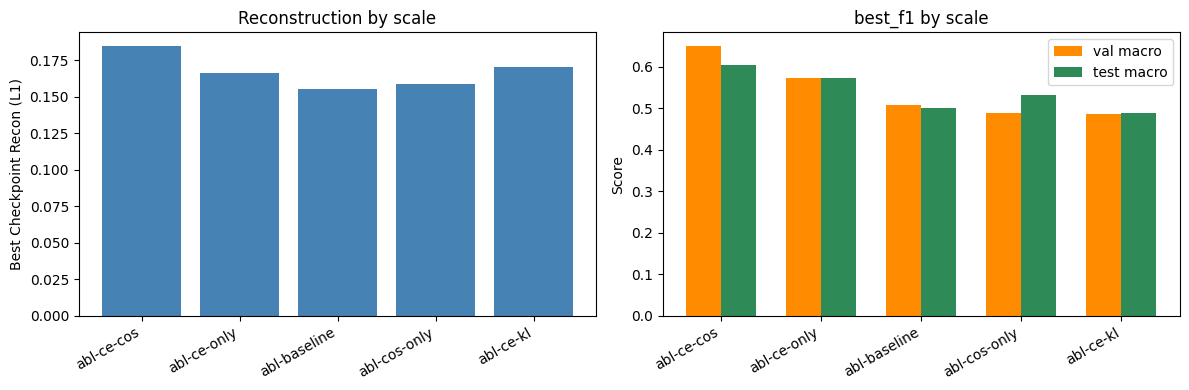

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(all_results)

# Fair cross weight_emo selection:
# 1) keep models within 1% of the best reconstruction
# 2) among them select highest balanced emotion score (macro acc if available)
# H2 recon-band relaxed to mirror 06 (CE+KL inherently shifts coeff L1).
# Selection still maximizes F1 inside the band; final H2 verdict on rendered videos.
baseline_recon = df.loc[df["scale"] == 0.0, "best_recon"].iloc[0]
best_recon = baseline_recon  # baseline is the floor; band measured from it
recon_tol = 1.5 * baseline_recon
score_col = "best_f1" if "best_f1" in df.columns else ("best_emo_macro_acc" if "best_emo_macro_acc" in df.columns else "best_emo_accuracy")

df["within_recon_band"] = df["best_recon"] <= (best_recon + recon_tol)
df["selection_score"] = df[score_col].where(df["within_recon_band"], -1.0)

df = df.sort_values(
    ["selection_score", "best_recon", score_col, "best_val"],
    ascending=[False, True, False, True],
).reset_index(drop=True)

print(
    "Selection rule: maximize F1 among models within +150% of baseline recon "
    f"(baseline={baseline_recon:.4f}, band ≤ {baseline_recon + recon_tol:.4f}). "
    f"Final H2 verdict uses rendered-video metrics (cell 10), not val coeff L1."
)

summary_cols = [
    "name", "scale", "w_ce", "w_cos", "w_kl", "best_recon", "best_emo_accuracy", "best_emo_macro_acc", "best_val",
    "ckpt_epoch", "best_total_epoch", "train_valid_ratio_at_ckpt", "val_valid_ratio_at_ckpt",
    "within_recon_band",
]
summary_cols = [c for c in summary_cols if c in df.columns]
print(df[summary_cols].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(df["name"], df["best_recon"], color="steelblue")
axes[0].set_ylabel("Best Checkpoint Recon (L1)")
axes[0].set_title("Reconstruction by scale")

if "test_emo_macro_acc" in df.columns:
    xn = np.arange(len(df))
    w = 0.35
    axes[1].bar(xn - w / 2, df[score_col], w, label="val macro", color="darkorange")
    axes[1].bar(xn + w / 2, df["test_emo_macro_acc"], w, label="test macro", color="seagreen")
    axes[1].set_xticks(xn)
    axes[1].set_xticklabels(df["name"])
    axes[1].legend()
else:
    axes[1].bar(df["name"], df[score_col], color="darkorange")
axes[1].set_ylabel("Score")
axes[1].set_title(f"{score_col} by scale")

for ax in axes:
    ax.tick_params(axis="x", labelrotation=30)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")

plt.tight_layout()
plt.show()


In [9]:
best_emo_df = df[df["scale"] > 0]
if len(best_emo_df) > 0:
    best_name = best_emo_df.iloc[0]["name"]
    best_scale = float(best_emo_df.iloc[0]["scale"])
else:
    best_name = df.iloc[0]["name"]
    best_scale = float(df.iloc[0]["scale"])
best_weight_emo = best_scale  # legacy alias for evaluate(...) gate logic

best_netG = load_sadtalker_netg(SADTALKER_CKPT, DEVICE)
best_emo_head = build_emo_head()
best_pred_stub = PredCoeffToVideoStub().to(DEVICE)

try:
    ckpt = torch.load(OUT_DIR / best_name / "model.pth", map_location=DEVICE, weights_only=False)
except TypeError:
    ckpt = torch.load(OUT_DIR / best_name / "model.pth", map_location=DEVICE)
best_netG.load_state_dict(ckpt["netG"])
best_emo_head.load_state_dict(ckpt["emo_head"])
best_pred_stub.load_state_dict(ckpt["pred_video_stub"])
best_audio_proj = best_video_proj = None
if "audio_proj" in ckpt and "video_proj" in ckpt:
    best_audio_proj = nn.Linear(AUDIO_DIM, PROJ_DIM).to(DEVICE)
    best_video_proj = nn.Linear(VIDEO_DIM, PROJ_DIM).to(DEVICE)
    best_audio_proj.load_state_dict(ckpt["audio_proj"])
    best_video_proj.load_state_dict(ckpt["video_proj"])
# Load saved composite weights so evaluate uses the same loss as training.
global emo_loss_fn
emo_loss_fn = EmotionLossComposite(
    w_ce=float(ckpt.get("w_ce", 0.0)),
    w_cos=float(ckpt.get("w_cos", 0.0)),
    w_kl=float(ckpt.get("w_kl", 0.0)),
)

best_w_coeff = float(ckpt.get("w_coeff_exp", W_COEFF_EXP))
best_mode = ckpt.get("unfreeze_mode", "unknown")
best_ckpt_by = ckpt.get("checkpoint_by", "val_total")
best_ckpt_epoch = ckpt.get("ckpt_epoch", "unknown")
best_ckpt_score = ckpt.get("ckpt_score", None)

val_metrics = evaluate(best_netG, best_emo_head, best_pred_stub, best_audio_proj, best_video_proj, val_loader, best_weight_emo, best_w_coeff)
test_metrics = evaluate(best_netG, best_emo_head, best_pred_stub, best_audio_proj, best_video_proj, test_loader, best_weight_emo, best_w_coeff)

print(f"Loaded best model: {best_name} (scale={best_scale})")
print(f"Unfreeze mode: {best_mode}, W_COEFF_EXP={best_w_coeff}")
if isinstance(best_ckpt_score, (int, float)):
    print(f"Checkpoint: by={best_ckpt_by}, epoch={best_ckpt_epoch}, score={best_ckpt_score:.4f}")
else:
    print(f"Checkpoint: by={best_ckpt_by}, epoch={best_ckpt_epoch}")
def _print_metrics(label, m):
    print(f"\n{label}:")
    print(f"  Avg coeff L1:       {m['recon']:.4f}")
    print(f"  Emotion loss:       {m['emotion']:.4f}")
    print(f"  Emotion accuracy:   {m['emo_accuracy']:.4f}")
    print(f"  Emotion macro acc:  {m['emo_macro_acc']:.4f}")
    print(f"  F1:                 {m['f1']:.4f}")
    print(f"  Mean cosine sim:    {m['mean_cosine_sim']:.4f}")
    prf = m["per_emotion_prf"]
    rows = []
    for e in range(len(EMOTIONS)):
        rows.append(f"    {EMOTIONS[e]:>8s}  P={prf[e]['precision']:.3f}  R={prf[e]['recall']:.3f}  F1={prf[e]['f1']:.3f}  n={prf[e]['support']}")
    print("  Per-emotion P / R / F1:")
    print("\n".join(rows))

_print_metrics("Best model — validation", val_metrics)
_print_metrics("Best model — test (held-out, final evaluation)", test_metrics)


del best_netG, best_emo_head, best_pred_stub, best_audio_proj, best_video_proj
if torch.cuda.is_available():
    torch.cuda.empty_cache()


using safetensor as default


Loaded best model: abl-ce-cos (scale=1.0)
Unfreeze mode: upper_audio, W_COEFF_EXP=2.0
Checkpoint: by=f1, epoch=30, score=0.6506

Best model — validation:
  Avg coeff L1:       0.1850
  Emotion loss:       0.0000
  Emotion accuracy:   0.6562
  Emotion macro acc:  0.6562
  F1:                 0.6506
  Mean cosine sim:    0.0000
  Per-emotion P / R / F1:
       happy  P=0.667  R=1.000  F1=0.800  n=24
         sad  P=0.483  R=0.583  F1=0.528  n=24
       angry  P=1.000  R=0.542  F1=0.703  n=24
     disgust  P=0.667  R=0.500  F1=0.571  n=24

Best model — test (held-out, final evaluation):
  Avg coeff L1:       0.1811
  Emotion loss:       0.0000
  Emotion accuracy:   0.6042
  Emotion macro acc:  0.6042
  F1:                 0.5558
  Mean cosine sim:    0.0000
  Per-emotion P / R / F1:
       happy  P=0.522  R=1.000  F1=0.686  n=24
         sad  P=0.750  R=0.125  F1=0.214  n=24
       angry  P=0.762  R=0.667  F1=0.711  n=24
     disgust  P=0.600  R=0.625  F1=0.612  n=24


Baseline: abl-baseline  |  Best emotion-aware: abl-ce-cos
using safetensor as default
using safetensor as default
Evaluating baseline (val)...


Evaluating best (val)...



=== Statistical significance (val, paired where aligned) ===
Coeff L1 — paired t-test: t=-26.3119, p=2.0610e-45
Coeff L1 — Wilcoxon signed-rank: W=0.0, p=1.7813e-17
Emo acc (emo_head) — McNemar: χ²=6.7222, p=9.5219e-03 (n01=3, n10=15)

=== Success criterion (coefficient-level, no LSE-C — see Cell 10 for rendered) ===
  ΔF1 = +0.1434 (≥ +0.10 required)   McNemar p = 9.5219e-03 (< 0.05 required)  → PASS

=== Baseline vs Best comparison ===
      metric  abl-baseline  abl-ce-cos      p-value    delta
    coeff L1      0.155408    0.184963 1.781294e-17 0.029556
emo_accuracy      0.531250    0.656250 9.521891e-03 0.125000
          F1      0.507256    0.650608 9.521891e-03 0.143352

=== Per-emotion precision / recall / F1 ===
emotion  abl-baseline_P  abl-baseline_R  abl-baseline_F1  abl-ce-cos_P  abl-ce-cos_R  abl-ce-cos_F1  delta_F1
  happy        0.687500        0.916667         0.785714      0.666667      1.000000       0.800000  0.014286
    sad        0.407407        0.458333         

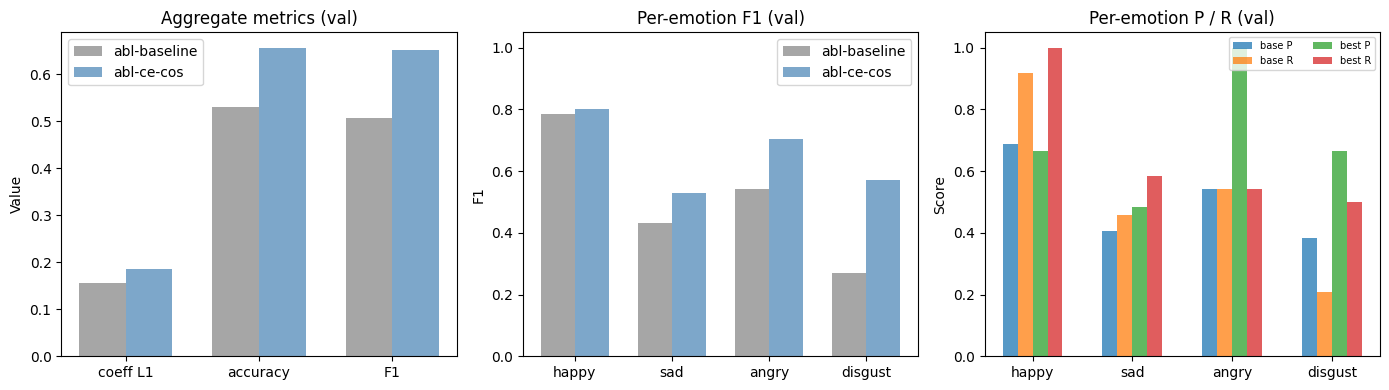

In [10]:
"""Baseline vs best: comparison + statistical significance (p-values)."""
from scipy import stats
from sklearn.metrics import precision_recall_fscore_support, f1_score

baseline_name = df.loc[df["scale"] == 0.0, "name"].iloc[0]
best_emo_df = df.loc[df["scale"] > 0.0]
best_cmp_name = best_emo_df.iloc[0]["name"]
print(f"Baseline: {baseline_name}  |  Best emotion-aware: {best_cmp_name}")


def load_variant(name):
    row = df[df["name"] == name].iloc[0]
    s = float(row["scale"])
    w_ce_v = float(row.get("w_ce", 0.0))
    w_cos_v = float(row.get("w_cos", 0.0))
    w_kl_v = float(row.get("w_kl", 0.0))
    netG = load_sadtalker_netg(SADTALKER_CKPT, DEVICE)
    emo_head = build_emo_head()
    try:
        ckpt = torch.load(OUT_DIR / name / "model.pth", map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(OUT_DIR / name / "model.pth", map_location=DEVICE)
    netG.load_state_dict(ckpt["netG"])
    emo_head.load_state_dict(ckpt["emo_head"])
    pred_stub = PredCoeffToVideoStub().to(DEVICE)
    pred_stub.load_state_dict(ckpt["pred_video_stub"])
    w_coeff = float(ckpt.get("w_coeff_exp", W_COEFF_EXP))
    return netG, emo_head, pred_stub, s, w_ce_v, w_cos_v, w_kl_v, w_coeff


@torch.no_grad()
def eval_per_sample(netG, emo_head, loader):
    """Per-sample coeff L1 and emo_head correctness for paired tests."""
    netG.eval()
    emo_head.eval()

    sample_recons = []
    sample_correct = []
    all_labels = []
    all_preds = []
    correct_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    total_by_emo = {e: 0 for e in range(len(EMOTIONS))}

    for batch in tqdm(loader, leave=False, desc="Eval"):
        labels = batch["emotion"].to(DEVICE)
        for i, indiv_mels in enumerate(batch["indiv_mels"]):
            try:
                gt_exp = batch["gt_exp"][i].float().to(DEVICE)
                if gt_exp.ndim != 2 or gt_exp.shape[1] != 64 or gt_exp.shape[0] < 2:
                    continue

                indiv_clip, gt_clip = slice_inputs_for_forward(
                    indiv_mels.float(),
                    gt_exp,
                    max_frames=MAX_FRAMES_EVAL,
                    random_window=False,
                )
                if indiv_clip is None:
                    continue

                ref_coeff_70 = make_ref_coeff_70(gt_clip)
                bd = make_batch_dict(indiv_clip, ref_coeff_70, DEVICE)
                pred = predict_exp_coeff(netG, bd).squeeze(0)
                pred_t, gt_t = trim_pair(pred, gt_clip)
                if pred_t is None:
                    continue

                per_l1 = F.l1_loss(pred_t, gt_t).item()
                sample_recons.append(per_l1)

                feats = make_emo_features(pred_t)
                logits = emo_head(feats.unsqueeze(0))
                lab = labels[i].view(1).to(DEVICE)
                p = int(logits.argmax(dim=1).item())
                e = int(labels[i].item())
                hit = (p == e)
                sample_correct.append(hit)
                all_labels.append(e)
                all_preds.append(p)
                total_by_emo[e] += 1
                if hit:
                    correct_by_emo[e] += 1
            except Exception:
                continue

    all_labels_arr = np.array(all_labels)
    all_preds_arr = np.array(all_preds)

    per_emotion_prf = {}
    emo_f1 = 0.0
    if len(all_labels) > 0:
        prec, rec, f1, sup = precision_recall_fscore_support(
            all_labels_arr, all_preds_arr, labels=list(range(len(EMOTIONS))), zero_division=0,
        )
        emo_f1 = float(f1_score(all_labels_arr, all_preds_arr, labels=list(range(len(EMOTIONS))), average="macro", zero_division=0))
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": float(prec[e]), "recall": float(rec[e]), "f1": float(f1[e]), "support": int(sup[e])}
    else:
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": 0.0, "recall": 0.0, "f1": 0.0, "support": 0}

    return {
        "recon_samples": np.array(sample_recons, dtype=np.float64),
        "correct": np.array(sample_correct, dtype=bool),
        "emo_accuracy": float(np.mean(sample_correct)) if sample_correct else 0.0,
        "f1": emo_f1,
        "recon": float(np.mean(sample_recons)) if sample_recons else float("inf"),
        "by_emotion": {
            e: correct_by_emo[e] / total_by_emo[e] if total_by_emo[e] > 0 else 0.0
            for e in range(len(EMOTIONS))
        },
        "per_emotion_prf": per_emotion_prf,
    }


baseline_netG, baseline_head, baseline_stub, baseline_scale, baseline_wce, baseline_wcos, baseline_wkl, baseline_wc = load_variant(
    baseline_name
)
best_netG, best_head, best_stub, best_scale, best_wce, best_wcos, best_wkl, best_wc = load_variant(best_cmp_name)

print("Evaluating baseline (val)...")
baseline_metrics = eval_per_sample(baseline_netG, baseline_head, val_loader)
print("Evaluating best (val)...")
best_metrics = eval_per_sample(best_netG, best_head, val_loader)

# Paired tests on same loader order — samples skipped in one model break pairing; filter common length
n = min(len(baseline_metrics["recon_samples"]), len(best_metrics["recon_samples"]))
br = baseline_metrics["recon_samples"][:n]
bst = best_metrics["recon_samples"][:n]
bc = baseline_metrics["correct"][:n]
ec = best_metrics["correct"][:n]

if n < 2:
    t_stat, p_ttest = float("nan"), float("nan")
    w_stat, p_wilcox = float("nan"), float("nan")
else:
    t_stat, p_ttest = stats.ttest_rel(br, bst)
    try:
        w_stat, p_wilcox = stats.wilcoxon(br, bst)
    except ValueError:
        w_stat, p_wilcox = float("nan"), float("nan")

n01 = int((bc & ~ec).sum())
n10 = int((~bc & ec).sum())
mcnemar_chi2 = (abs(n01 - n10) - 1) ** 2 / max(n01 + n10, 1)
p_mcnemar = 1 - stats.chi2.cdf(mcnemar_chi2, df=1) if (n01 + n10) > 0 else 1.0

delta_f1 = best_metrics["f1"] - baseline_metrics["f1"]

print("\n=== Statistical significance (val, paired where aligned) ===")
print(f"Coeff L1 — paired t-test: t={t_stat:.4f}, p={p_ttest:.4e}")
print(f"Coeff L1 — Wilcoxon signed-rank: W={w_stat:.1f}, p={p_wilcox:.4e}")
print(f"Emo acc (emo_head) — McNemar: χ²={mcnemar_chi2:.4f}, p={p_mcnemar:.4e} (n01={n01}, n10={n10})")

f1_pass = delta_f1 >= 0.10 and p_mcnemar < 0.05
print("\n=== Success criterion (coefficient-level, no LSE-C — see Cell 10 for rendered) ===")
print(f"  ΔF1 = {delta_f1:+.4f} (≥ +0.10 required)   McNemar p = {p_mcnemar:.4e} (< 0.05 required)  → {'PASS' if f1_pass else 'FAIL'}")

cmp = pd.DataFrame({
    "metric": ["coeff L1", "emo_accuracy", "F1"],
    baseline_name: [baseline_metrics["recon"], baseline_metrics["emo_accuracy"], baseline_metrics["f1"]],
    best_cmp_name: [best_metrics["recon"], best_metrics["emo_accuracy"], best_metrics["f1"]],
    "p-value": [p_wilcox, p_mcnemar, p_mcnemar],
})
cmp["delta"] = cmp[best_cmp_name] - cmp[baseline_name]
print("\n=== Baseline vs Best comparison ===")
print(cmp.to_string(index=False))

per_emo_rows = []
for e in range(len(EMOTIONS)):
    bp = baseline_metrics["per_emotion_prf"][e]
    ep = best_metrics["per_emotion_prf"][e]
    per_emo_rows.append({
        "emotion": EMOTIONS[e],
        f"{baseline_name}_P": bp["precision"],
        f"{baseline_name}_R": bp["recall"],
        f"{baseline_name}_F1": bp["f1"],
        f"{best_cmp_name}_P": ep["precision"],
        f"{best_cmp_name}_R": ep["recall"],
        f"{best_cmp_name}_F1": ep["f1"],
        "delta_F1": ep["f1"] - bp["f1"],
    })
per_emo = pd.DataFrame(per_emo_rows)
print("\n=== Per-emotion precision / recall / F1 ===")
print(per_emo.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

x_agg = np.arange(3)
w_agg = 0.35
axes[0].bar(
    x_agg - w_agg / 2,
    [baseline_metrics["recon"], baseline_metrics["emo_accuracy"], baseline_metrics["f1"]],
    w_agg, label=baseline_name, color="gray", alpha=0.7,
)
axes[0].bar(
    x_agg + w_agg / 2,
    [best_metrics["recon"], best_metrics["emo_accuracy"], best_metrics["f1"]],
    w_agg, label=best_cmp_name, color="steelblue", alpha=0.7,
)
axes[0].set_xticks(x_agg)
axes[0].set_xticklabels(["coeff L1", "accuracy", "F1"])
axes[0].set_ylabel("Value")
axes[0].legend()
axes[0].set_title("Aggregate metrics (val)")

x = np.arange(len(EMOTIONS))
w = 0.35
axes[1].bar(x - w / 2, per_emo[f"{baseline_name}_F1"], w, label=baseline_name, color="gray", alpha=0.7)
axes[1].bar(x + w / 2, per_emo[f"{best_cmp_name}_F1"], w, label=best_cmp_name, color="steelblue", alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(EMOTIONS)
axes[1].set_ylabel("F1")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].set_title("Per-emotion F1 (val)")

bar_width = 0.15
x_pr = np.arange(len(EMOTIONS))
for offset, (col, lbl) in enumerate([
    (f"{baseline_name}_P", "base P"), (f"{baseline_name}_R", "base R"),
    (f"{best_cmp_name}_P", "best P"), (f"{best_cmp_name}_R", "best R"),
]):
    axes[2].bar(x_pr + (offset - 1.5) * bar_width, per_emo[col], bar_width, label=lbl, alpha=0.75)
axes[2].set_xticks(x_pr)
axes[2].set_xticklabels(EMOTIONS)
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 1.05)
axes[2].legend(fontsize=7, ncol=2)
axes[2].set_title("Per-emotion P / R (val)")

plt.tight_layout()
plt.show()

del baseline_netG, baseline_head, baseline_stub
del best_netG, best_head, best_stub
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


[align_img] patched /content/SadTalker/src/face3d/util/preprocess.py for NumPy 2.x
  baseline = abl-baseline, best emotion-aware = abl-ce-cos
Evaluating rendered videos on 24 validation samples...
using safetensor as default


landmark Det:: 100%|██████████| 1/1 [00:00<00:00,  2.43it/s]

3DMM Extraction In Video:: 100%|██████████| 1/1 [00:02<00:00,  2.52s/it]

mel:: 100%|██████████| 83/83 [00:00<00:00, 73367.17it/s]

audio2exp:: 100%|██████████| 9/9 [00:00<00:00, 18.84it/s]

Face Renderer:: 100%|██████████| 83/83 [00:09<00:00,  9.20it/s]


The generated video is named /content/sadtalker_loss_ablation_4emo/_render_eval/abl-baseline/01-01-03-01-01-01-09/source##01-01-03-01-01-01-09.mp4


landmark Det:: 100%|██████████| 1/1 [00:00<00:00, 39.37it/s]

3DMM Extraction In Video:: 100%|██████████| 1/1 [00:00<00:00, 166.84it/s]

mel:: 100%|██████████| 88/88 [00:00<00:00, 77786.88it/s]

audio2exp:: 100%|██████████| 9/9 [00:00<00:00, 18.57it/s]

Face Renderer:: 100%|██████████| 88/88 [00:05<00:00, 16.04it/s]


...

The generated video is named /content/sadtalker_loss_ablation_4emo/_render_eval/abl-ce-cos/01-01-07-02-01-01-09/source##01-01-07-02-01-01-09.mp4


landmark Det:: 100%|██████████| 1/1 [00:00<00:00, 40.89it/s]

3DMM Extraction In Video:: 100%|██████████| 1/1 [00:00<00:00, 161.46it/s]

mel:: 100%|██████████| 88/88 [00:00<00:00, 66301.19it/s]

audio2exp:: 100%|██████████| 9/9 [00:00<00:00, 711.81it/s]

Face Renderer:: 100%|██████████| 88/88 [00:05<00:00, 16.01it/s]


The generated video is named /content/sadtalker_loss_ablation_4emo/_render_eval/abl-ce-cos/01-01-07-02-01-02-09/source##01-01-07-02-01-02-09.mp4


Render+eval abl-ce-cos: 100%|██████████| 24/24 [02:44<00:00,  6.87s/it]



=== Statistical significance (rendered videos) ===
Emo acc   — McNemar: χ²=0.0000, p=1.0000e+00 (n01=3, n10=4)
LSE-C     — paired t-test: t=0.8729, p=3.9173e-01

=== Success criteria (rendered videos) ===
  ΔF1 = +0.0529 (≥ +0.10 required)   McNemar p = 1.0000e+00 (< 0.05 required)  → FAIL
  ΔLSE-C = -19.49% (≤ ±2% required)  paired t p = 3.9173e-01 (< 0.05 required)  → FAIL
    LSE-C change exceeds 2% but is not statistically significant

=== Rendered-video baseline vs best ===
           metric  abl-baseline  abl-ce-cos  p-value     delta
     emo_accuracy      0.583333    0.625000 1.000000  0.041667
               f1      0.547078    0.600000 1.000000  0.052922
          LSE-C ↑      0.007314    0.005888 0.391728 -0.001426
          LSE-D ↓      0.992686    0.994112 0.391728  0.001426
         failures      0.000000    0.000000      NaN  0.000000
evaluated_samples     24.000000   24.000000      NaN  0.000000

=== Rendered-video per-emotion P / R / F1 ===
emotion  abl-baseline_P  ab

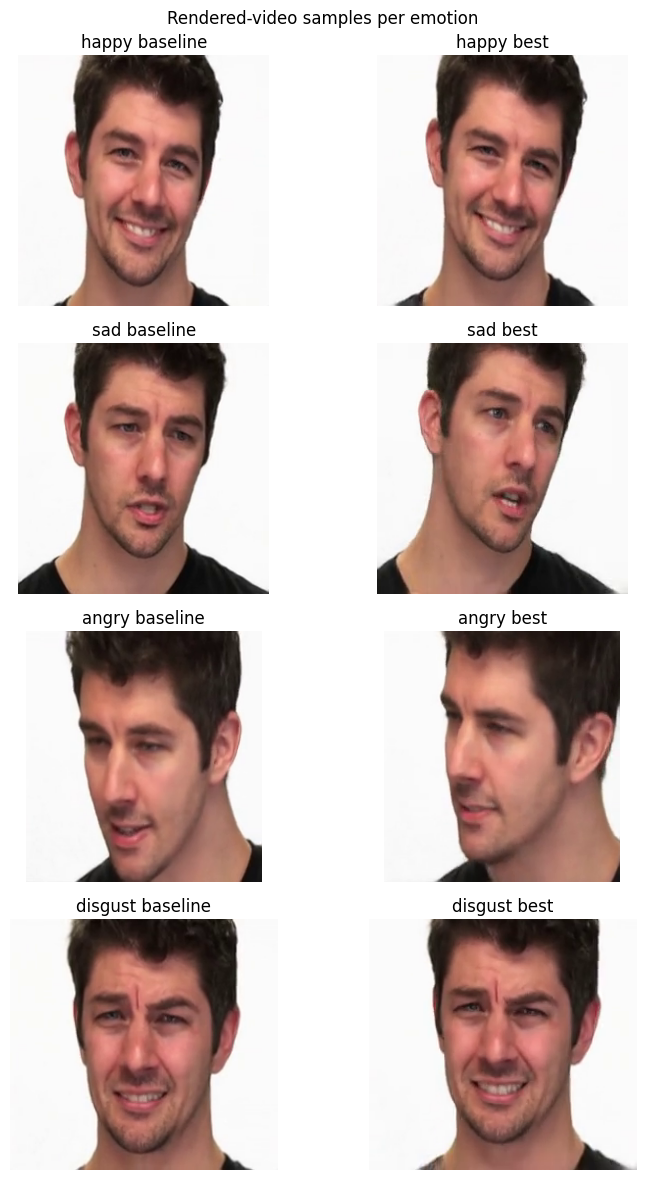

In [11]:
"""04-style evaluation on rendered SadTalker videos (expensive)."""

# ── NumPy 2.x compatibility fix for SadTalker preprocess.align_img ───────────
# NumPy ≥1.25 raises ValueError("inhomogeneous shape") on
#   np.array([w0, h0, s, t[0], t[1]])
# when t[0]/t[1] are length-1 arrays (which they often are after recent
# upstream changes). We sed-patch SadTalker source ONCE in-place so all
# subsequent imports use the corrected line. Idempotent: re-running has no
# effect after the first successful patch.
import subprocess as _sp
import os as _os
_pp_path = "/content/SadTalker/src/face3d/util/preprocess.py"
if _os.path.exists(_pp_path):
    # Replace `trans_params = np.array([w0, h0, s, t[0], t[1]])`
    # with    `trans_params = np.array([float(w0), float(h0), float(s), float(t[0]), float(t[1])], dtype=np.float64)`
    _sp.run([
        "sed", "-i",
        r"s|trans_params = np.array(\[w0, h0, s, t\[0\], t\[1\]\])|trans_params = np.array([float(w0), float(h0), float(s), float(t[0]), float(t[1])], dtype=np.float64)|",
        _pp_path,
    ], check=True)
    # Reload if already imported (Colab kernel restart not needed)
    import sys, importlib
    for _mod_name in list(sys.modules):
        if _mod_name.startswith("src.face3d.util.preprocess") or _mod_name.endswith(".preprocess"):
            try:
                importlib.reload(sys.modules[_mod_name])
            except Exception:
                pass
    print(f"[align_img] patched {_pp_path} for NumPy 2.x")
else:
    print(f"[align_img] {_pp_path} not found — skip patch (run after cloning SadTalker)")

import numpy as np


# NumPy 2.x compatibility for SadTalker imports
if not hasattr(np, "VisibleDeprecationWarning"):
    np.VisibleDeprecationWarning = DeprecationWarning
# Older SadTalker internals still use deprecated aliases (np.float, etc.)
if not hasattr(np, "float"):
    np.float = float
if not hasattr(np, "int"):
    np.int = int
if not hasattr(np, "bool"):
    np.bool = bool

import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
from torchvision.io import read_video
import sys
import types

# Avoid optional gfpgan/basicsr import chain when enhancer=None.
# Force a lightweight stub regardless of prior imports.
_stub = types.ModuleType("src.utils.face_enhancer")
_stub.enhancer_list = []

def enhancer_generator_with_len(*args, **kwargs):
    return [], 0

_stub.enhancer_generator_with_len = enhancer_generator_with_len
sys.modules["src.utils.face_enhancer"] = _stub

from transformers import AutoImageProcessor, AutoModelForVideoClassification

from src.utils.preprocess import CropAndExtract
from src.test_audio2coeff import Audio2Coeff
from src.facerender.animate import AnimateFromCoeff
from src.generate_batch import get_data
from src.generate_facerender_batch import get_facerender_data
from src.utils.init_path import init_path
import librosa
import subprocess

MAX_EVAL_SAMPLES = 24          # set to int (e.g. 12) for a faster smoke test

# ── SyncNet (Wav2Lip lipsync expert) for LSE-C / LSE-D ──────────────

SYNCNET_CKPT = Path("/content/Wav2Lip/checkpoints/lipsync_expert.pth")
SYNCNET_URL = "https://huggingface.co/Nekochu/Wav2Lip/resolve/main/lipsync_expert.pth"
SYNCNET_T = 5
SYNCNET_MEL_STEP = 16
SYNCNET_FPS = 25
SYNCNET_SR = 16000


class _SyncNetConv(nn.Module):
    def __init__(self, cin, cout, kernel_size, stride, padding, residual=False):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(cin, cout, kernel_size, stride, padding),
            nn.BatchNorm2d(cout),
        )
        self.act = nn.ReLU()
        self.residual = residual

    def forward(self, x):
        out = self.conv_block(x)
        if self.residual:
            out += x
        return self.act(out)


class SyncNet_color(nn.Module):
    def __init__(self):
        super().__init__()
        self.face_encoder = nn.Sequential(
            _SyncNetConv(15, 32, (7, 7), 1, 3),
            _SyncNetConv(32, 64, 5, (1, 2), 1),
            _SyncNetConv(64, 64, 3, 1, 1, residual=True),
            _SyncNetConv(64, 64, 3, 1, 1, residual=True),
            _SyncNetConv(64, 128, 3, 2, 1),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 256, 3, 2, 1),
            _SyncNetConv(256, 256, 3, 1, 1, residual=True),
            _SyncNetConv(256, 256, 3, 1, 1, residual=True),
            _SyncNetConv(256, 512, 3, 2, 1),
            _SyncNetConv(512, 512, 3, 1, 1, residual=True),
            _SyncNetConv(512, 512, 3, 1, 1, residual=True),
            _SyncNetConv(512, 512, 3, 2, 1),
            _SyncNetConv(512, 512, 3, 1, 0),
            _SyncNetConv(512, 512, 1, 1, 0),
        )
        self.audio_encoder = nn.Sequential(
            _SyncNetConv(1, 32, 3, 1, 1),
            _SyncNetConv(32, 32, 3, 1, 1, residual=True),
            _SyncNetConv(32, 32, 3, 1, 1, residual=True),
            _SyncNetConv(32, 64, 3, (3, 1), 1),
            _SyncNetConv(64, 64, 3, 1, 1, residual=True),
            _SyncNetConv(64, 64, 3, 1, 1, residual=True),
            _SyncNetConv(64, 128, 3, 3, 1),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 256, 3, (3, 2), 1),
            _SyncNetConv(256, 256, 3, 1, 1, residual=True),
            _SyncNetConv(256, 256, 3, 1, 1, residual=True),
            _SyncNetConv(256, 512, 3, 1, 0),
            _SyncNetConv(512, 512, 1, 1, 0),
        )

    def forward(self, audio_sequences, face_sequences):
        face_embedding = self.face_encoder(face_sequences)
        audio_embedding = self.audio_encoder(audio_sequences)
        audio_embedding = audio_embedding.view(audio_embedding.size(0), -1)
        face_embedding = face_embedding.view(face_embedding.size(0), -1)
        audio_embedding = F.normalize(audio_embedding, p=2, dim=1)
        face_embedding = F.normalize(face_embedding, p=2, dim=1)
        return audio_embedding, face_embedding


def load_syncnet(ckpt_path, device):
    ckpt_path = Path(ckpt_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    def _load_ckpt(path):
        try:
            return torch.load(path, map_location=device, weights_only=False)
        except TypeError:
            return torch.load(path, map_location=device)

    if not ckpt_path.exists():
        print(f"Downloading SyncNet checkpoint → {ckpt_path}")
        subprocess.check_call(["wget", "-q", SYNCNET_URL, "-O", str(ckpt_path)])

    model = SyncNet_color()
    try:
        ckpt = _load_ckpt(ckpt_path)
        sd = ckpt.get("state_dict", ckpt)
        sd = {k.replace("module.", ""): v for k, v in sd.items()}
        model.load_state_dict(sd, strict=True)
    except RuntimeError:
        print("SyncNet checkpoint mismatch. Re-downloading official lipsync_expert.pth...")
        subprocess.check_call(["wget", "-q", SYNCNET_URL, "-O", str(ckpt_path)])
        ckpt = _load_ckpt(ckpt_path)
        sd = ckpt.get("state_dict", ckpt)
        sd = {k.replace("module.", ""): v for k, v in sd.items()}
        model.load_state_dict(sd, strict=True)

    model.to(device).eval()
    return model


def _wav2lip_mel(audio_path):
    wav, _ = librosa.load(str(audio_path), sr=SYNCNET_SR)
    S = np.abs(librosa.stft(wav, n_fft=800, hop_length=200, win_length=800))
    mel_basis = librosa.filters.mel(sr=SYNCNET_SR, n_fft=800, n_mels=80, fmin=55, fmax=7600)
    mel = np.log(np.maximum(np.dot(mel_basis, S), 1e-5))
    return mel  # (80, T_mel)


@torch.no_grad()
def compute_lse(video_path, audio_path, syncnet):
    """LSE-C (higher=better sync) and LSE-D (lower=better sync) for one video."""
    frames, _, _ = read_video(str(video_path), pts_unit="sec")
    if frames.shape[0] < SYNCNET_T:
        return float("nan"), float("nan")

    mel = _wav2lip_mel(audio_path)

    # Lip crops: resize face to 96x96, take lower half → (48, 96)
    crops = []
    for fr in frames:
        pil = Image.fromarray(fr.numpy().astype(np.uint8)).resize((96, 96), Image.BILINEAR)
        arr = np.array(pil, dtype=np.float32) / 255.0
        crops.append(arr[48:, :, :])  # (48, 96, 3)

    mel_mult = 80.0 / SYNCNET_FPS
    cos_sims = []
    for i in range(len(crops) - SYNCNET_T + 1):
        mel_start = int(i * mel_mult)
        if mel_start + SYNCNET_MEL_STEP > mel.shape[1]:
            break
        vid = np.concatenate([crops[i + j].transpose(2, 0, 1) for j in range(SYNCNET_T)], axis=0)
        vid_t = torch.FloatTensor(vid).unsqueeze(0).to(DEVICE)
        aud_t = torch.FloatTensor(mel[:, mel_start:mel_start + SYNCNET_MEL_STEP]).unsqueeze(0).unsqueeze(0).to(DEVICE)
        a_emb, v_emb = syncnet(aud_t, vid_t)
        cos_sims.append(F.cosine_similarity(a_emb, v_emb).item())

    if not cos_sims:
        return float("nan"), float("nan")
    lse_c = float(np.mean(cos_sims))
    lse_d = float(np.mean([1.0 - s for s in cos_sims]))
    return lse_c, lse_d


def pick_eval_samples(samples, max_n=None):
    vals = [s for s in samples if s["emotion_idx"] in REMAP]
    if max_n is None or max_n >= len(vals):
        return vals

    by_emo = {k: [] for k in REMAP.keys()}
    for s in vals:
        by_emo[s["emotion_idx"]].append(s)

    picked = []
    per_class = max_n // len(by_emo)
    for k in sorted(by_emo.keys()):
        picked.extend(by_emo[k][:per_class])

    if len(picked) < max_n:
        used_ids = {s["sample_id"] for s in picked}
        leftovers = [s for s in vals if s["sample_id"] not in used_ids]
        picked.extend(leftovers[: max_n - len(picked)])

    return picked


def build_sadtalker_runtime(netg_state_dict):
    sadtalker_paths = init_path(
        str(SADTALKER_CKPT),
        "/content/SadTalker/src/config",
        "256",
        False,
        "crop",
    )

    preprocess_model = CropAndExtract(sadtalker_paths, DEVICE)
    audio_to_coeff = Audio2Coeff(sadtalker_paths, DEVICE)
    audio_to_coeff.audio2exp_model.netG.load_state_dict(netg_state_dict, strict=True)
    animate_from_coeff = AnimateFromCoeff(sadtalker_paths, DEVICE)

    return preprocess_model, audio_to_coeff, animate_from_coeff


def render_one_sample(sample, runtime, work_dir):
    preprocess_model, audio_to_coeff, animate_from_coeff = runtime

    sample_dir = Path(work_dir) / sample["sample_id"]
    sample_dir.mkdir(parents=True, exist_ok=True)

    frames = np.load(sample["frames_path"])  # (T, H, W, 3), uint8
    src_img_path = sample_dir / "source.png"
    Image.fromarray(frames[0].astype(np.uint8)).save(src_img_path)

    first_frame_dir = sample_dir / "first_frame_dir"
    first_frame_dir.mkdir(parents=True, exist_ok=True)

    first_coeff_path, crop_pic_path, crop_info = preprocess_model.generate(
        str(src_img_path),
        str(first_frame_dir),
        "crop",
        source_image_flag=True,
        pic_size=256,
    )
    if first_coeff_path is None:
        raise RuntimeError(f"Could not extract source coeff for {sample['sample_id']}")

    batch = get_data(first_coeff_path, sample["audio_path"], DEVICE, None, still=False)
    coeff_path = audio_to_coeff.generate(batch, str(sample_dir), pose_style=0, ref_pose_coeff_path=None)

    data = get_facerender_data(
        coeff_path,
        crop_pic_path,
        first_coeff_path,
        sample["audio_path"],
        batch_size=1,
        input_yaw_list=None,
        input_pitch_list=None,
        input_roll_list=None,
        expression_scale=1.0,
        still_mode=False,
        preprocess="crop",
        size=256,
    )

    result_video = animate_from_coeff.generate(
        data,
        str(sample_dir),
        str(src_img_path),
        crop_info,
        enhancer=None,
        background_enhancer=None,
        preprocess="crop",
        img_size=256,
    )

    return Path(result_video)


def load_video_emotion_model(model_path):
    processor = AutoImageProcessor.from_pretrained(model_path)
    model = AutoModelForVideoClassification.from_pretrained(model_path).to(DEVICE)
    model.eval()
    num_frames = getattr(model.config, "num_frames", 8)
    return processor, model, num_frames


@torch.no_grad()
def classify_rendered_video(video_path, processor, model, num_frames):
    frames, _, _ = read_video(str(video_path), pts_unit="sec")  # (T, H, W, C), uint8
    if frames.shape[0] == 0:
        raise RuntimeError(f"No frames decoded: {video_path}")

    idx = torch.linspace(0, frames.shape[0] - 1, steps=num_frames).long()
    idx = idx.clamp(0, frames.shape[0] - 1)
    sampled = frames[idx].cpu().numpy()

    inputs = processor(list(sampled), return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    logits = model(**inputs).logits
    n_lab = int(getattr(model.config, "num_labels", logits.shape[-1]))
    if n_lab == len(EMOTIONS):
        logits3 = logits
    else:
        logits3 = logits[:, WAV2LIP_TO_ENCODER]
    pred = logits3.argmax(dim=1).item()
    return pred


def evaluate_rendered_checkpoint(name, netg_state_dict, samples, processor, model, num_frames, out_root, syncnet=None):
    runtime = build_sadtalker_runtime(netg_state_dict)

    correct_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    total_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    confusion = np.zeros((len(EMOTIONS), len(EMOTIONS)), dtype=np.int64)
    all_labels = []
    all_preds = []
    lse_c_vals = []
    lse_d_vals = []

    failures = 0
    example_videos = {}

    model_dir = Path(out_root) / name
    model_dir.mkdir(parents=True, exist_ok=True)

    for sample in tqdm(samples, desc=f"Render+eval {name}"):
        gt_label = REMAP[sample["emotion_idx"]]
        try:
            video_path = render_one_sample(sample, runtime, model_dir)
            pred_label = classify_rendered_video(video_path, processor, model, num_frames)

            total_by_emo[gt_label] += 1
            all_labels.append(gt_label)
            all_preds.append(pred_label)
            confusion[gt_label, pred_label] += 1
            if pred_label == gt_label:
                correct_by_emo[gt_label] += 1

            if syncnet is not None:
                c, d = compute_lse(video_path, sample["audio_path"], syncnet)
                if not np.isnan(c):
                    lse_c_vals.append(c)
                    lse_d_vals.append(d)

            if gt_label not in example_videos:
                example_videos[gt_label] = str(video_path)
        except Exception as exc:
            failures += 1
            if failures <= 3:
                import traceback
                print(f"  RENDER FAILURE ({sample['sample_id']}): {exc}")
                traceback.print_exc()
            continue

    total_correct = sum(correct_by_emo.values())
    total_samples = sum(total_by_emo.values())

    by_emotion = {
        e: (correct_by_emo[e] / total_by_emo[e]) if total_by_emo[e] > 0 else 0.0
        for e in range(len(EMOTIONS))
    }

    per_emotion_prf = {}
    emo_f1 = 0.0
    if all_labels:
        from sklearn.metrics import precision_recall_fscore_support, f1_score
        prec, rec, f1, sup = precision_recall_fscore_support(
            all_labels, all_preds, labels=list(range(len(EMOTIONS))), zero_division=0,
        )
        emo_f1 = float(f1_score(all_labels, all_preds, labels=list(range(len(EMOTIONS))), average="macro", zero_division=0))
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": float(prec[e]), "recall": float(rec[e]), "f1": float(f1[e]), "support": int(sup[e])}
    else:
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": 0.0, "recall": 0.0, "f1": 0.0, "support": 0}

    correct = np.array([p == l for p, l in zip(all_preds, all_labels)], dtype=bool)

    return {
        "emo_accuracy": (total_correct / total_samples) if total_samples > 0 else 0.0,
        "f1": emo_f1,
        "lse_c": float(np.mean(lse_c_vals)) if lse_c_vals else float("nan"),
        "lse_d": float(np.mean(lse_d_vals)) if lse_d_vals else float("nan"),
        "lse_c_samples": np.array(lse_c_vals, dtype=np.float64),
        "correct": correct,
        "all_labels": np.array(all_labels),
        "all_preds": np.array(all_preds),
        "by_emotion": by_emotion,
        "per_emotion_prf": per_emotion_prf,
        "counts_by_emotion": total_by_emo,
        "confusion": confusion,
        "failures": failures,
        "n_evaluated": total_samples,
        "example_videos": example_videos,
    }


baseline_name = df.loc[df["scale"] == 0.0, "name"].iloc[0]
best_emo = df[df["scale"] > 0.0]
best_name = (best_emo.iloc[0]["name"] if len(best_emo) else df.iloc[0]["name"])
print(f"  baseline = {baseline_name}, best emotion-aware = {best_name}")

if not Path(BEST_VIDEO_PATH).exists():
    raise FileNotFoundError(
        f"Frozen video emotion encoder not found: {BEST_VIDEO_PATH}. "
        "Run 04 setup or set BEST_VIDEO_PATH to the correct checkpoint."
    )

processor, video_enc, video_frames = load_video_emotion_model(BEST_VIDEO_PATH)
syncnet = load_syncnet(SYNCNET_CKPT, DEVICE)

samples = pick_eval_samples(val_ds.samples, max_n=MAX_EVAL_SAMPLES)
print(f"Evaluating rendered videos on {len(samples)} validation samples...")

baseline_ckpt = torch.load(OUT_DIR / baseline_name / "model.pth", map_location=DEVICE)
best_ckpt = torch.load(OUT_DIR / best_name / "model.pth", map_location=DEVICE)

render_eval_root = OUT_DIR / "_render_eval"
render_eval_root.mkdir(parents=True, exist_ok=True)

baseline_render_metrics = evaluate_rendered_checkpoint(
    baseline_name,
    baseline_ckpt["netG"],
    samples,
    processor,
    video_enc,
    video_frames,
    render_eval_root,
    syncnet=syncnet,
)

best_render_metrics = evaluate_rendered_checkpoint(
    best_name,
    best_ckpt["netG"],
    samples,
    processor,
    video_enc,
    video_frames,
    render_eval_root,
    syncnet=syncnet,
)

# --- Statistical significance (rendered videos) ---
# McNemar's test on paired correct/incorrect
_bc = baseline_render_metrics["correct"]
_ec = best_render_metrics["correct"]
_rn = min(len(_bc), len(_ec))
_bc, _ec = _bc[:_rn], _ec[:_rn]
n01 = int((_bc & ~_ec).sum())
n10 = int((~_bc & _ec).sum())
mcnemar_chi2 = (abs(n01 - n10) - 1) ** 2 / max(n01 + n10, 1)
p_mcnemar = 1 - stats.chi2.cdf(mcnemar_chi2, df=1) if (n01 + n10) > 0 else 1.0

# LSE-C: paired t-test on per-video cosine similarities
_lse_b = baseline_render_metrics["lse_c_samples"]
_lse_e = best_render_metrics["lse_c_samples"]
_lse_n = min(len(_lse_b), len(_lse_e))
if _lse_n >= 2:
    t_lse, p_lse = stats.ttest_rel(_lse_b[:_lse_n], _lse_e[:_lse_n])
else:
    t_lse, p_lse = float("nan"), float("nan")

delta_f1 = best_render_metrics["f1"] - baseline_render_metrics["f1"]
delta_lse_c = best_render_metrics["lse_c"] - baseline_render_metrics["lse_c"]
delta_lse_c_pct = (delta_lse_c / abs(baseline_render_metrics["lse_c"]) * 100) if baseline_render_metrics["lse_c"] != 0 and not np.isnan(baseline_render_metrics["lse_c"]) else float("nan")

print("\n=== Statistical significance (rendered videos) ===")
print(f"Emo acc   — McNemar: χ²={mcnemar_chi2:.4f}, p={p_mcnemar:.4e} (n01={n01}, n10={n10})")
print(f"LSE-C     — paired t-test: t={t_lse:.4f}, p={p_lse:.4e}")

f1_pass = delta_f1 >= 0.10 and p_mcnemar < 0.05
lse_pass = np.isnan(delta_lse_c_pct) or (abs(delta_lse_c_pct) <= 2.0)
lse_sig = (not np.isnan(p_lse)) and p_lse < 0.05

print("\n=== Success criteria (rendered videos) ===")
print(f"  ΔF1 = {delta_f1:+.4f} (≥ +0.10 required)   McNemar p = {p_mcnemar:.4e} (< 0.05 required)  → {'PASS' if f1_pass else 'FAIL'}")
print(f"  ΔLSE-C = {delta_lse_c_pct:+.2f}% (≤ ±2% required)  paired t p = {p_lse:.4e} (< 0.05 required)  → {'PASS' if lse_pass else 'FAIL'}")
if lse_sig and not lse_pass:
    print("    LSE-C degradation is statistically significant — lip sync quality affected")
elif not lse_sig and not lse_pass:
    print("    LSE-C change exceeds 2% but is not statistically significant")

cmp = pd.DataFrame({
    "metric": ["emo_accuracy", "f1", "LSE-C ↑", "LSE-D ↓", "failures", "evaluated_samples"],
    baseline_name: [
        baseline_render_metrics["emo_accuracy"],
        baseline_render_metrics["f1"],
        baseline_render_metrics["lse_c"],
        baseline_render_metrics["lse_d"],
        baseline_render_metrics["failures"],
        baseline_render_metrics["n_evaluated"],
    ],
    best_name: [
        best_render_metrics["emo_accuracy"],
        best_render_metrics["f1"],
        best_render_metrics["lse_c"],
        best_render_metrics["lse_d"],
        best_render_metrics["failures"],
        best_render_metrics["n_evaluated"],
    ],
    "p-value": [p_mcnemar, p_mcnemar, p_lse, p_lse, float("nan"), float("nan")],
})
cmp["delta"] = cmp[best_name] - cmp[baseline_name]
print("\n=== Rendered-video baseline vs best ===")
print(cmp.to_string(index=False))

render_prf_rows = []
for e in range(len(EMOTIONS)):
    bp = baseline_render_metrics["per_emotion_prf"][e]
    ep = best_render_metrics["per_emotion_prf"][e]
    render_prf_rows.append({
        "emotion": EMOTIONS[e],
        f"{baseline_name}_P": bp["precision"],
        f"{baseline_name}_R": bp["recall"],
        f"{baseline_name}_F1": bp["f1"],
        f"{baseline_name}_n": bp["support"],
        f"{best_name}_P": ep["precision"],
        f"{best_name}_R": ep["recall"],
        f"{best_name}_F1": ep["f1"],
        f"{best_name}_n": ep["support"],
        "delta_F1": ep["f1"] - bp["f1"],
    })
per_emo = pd.DataFrame(render_prf_rows)
print("\n=== Rendered-video per-emotion P / R / F1 ===")
print(per_emo.to_string(index=False))

base_conf = pd.DataFrame(
    baseline_render_metrics["confusion"],
    index=[f"true_{e}" for e in EMOTIONS],
    columns=[f"pred_{e}" for e in EMOTIONS],
)
best_conf = pd.DataFrame(
    best_render_metrics["confusion"],
    index=[f"true_{e}" for e in EMOTIONS],
    columns=[f"pred_{e}" for e in EMOTIONS],
)
print("\n=== Baseline confusion (rendered videos) ===")
print(base_conf.to_string())
print("\n=== Best confusion (rendered videos) ===")
print(best_conf.to_string())


def load_mid_frame(video_path):
    v, _, _ = read_video(str(video_path), pts_unit="sec")
    if v.shape[0] == 0:
        return None
    return v[v.shape[0] // 2].cpu().numpy()


fig, axes = plt.subplots(len(EMOTIONS), 2, figsize=(8, 3 * len(EMOTIONS)))
if len(EMOTIONS) == 1:
    axes = np.array([axes])

for e in range(len(EMOTIONS)):
    base_v = baseline_render_metrics["example_videos"].get(e)
    best_v = best_render_metrics["example_videos"].get(e)

    base_fr = load_mid_frame(base_v) if base_v is not None else None
    best_fr = load_mid_frame(best_v) if best_v is not None else None

    ax0, ax1 = axes[e]
    if base_fr is not None:
        ax0.imshow(base_fr)
        ax0.set_title(f"{EMOTIONS[e]} baseline")
    else:
        ax0.text(0.5, 0.5, "N/A", ha="center", va="center")
        ax0.set_title(f"{EMOTIONS[e]} baseline")
    ax0.axis("off")

    if best_fr is not None:
        ax1.imshow(best_fr)
        ax1.set_title(f"{EMOTIONS[e]} best")
    else:
        ax1.text(0.5, 0.5, "N/A", ha="center", va="center")
        ax1.set_title(f"{EMOTIONS[e]} best")
    ax1.axis("off")

plt.suptitle("Rendered-video samples per emotion")
plt.tight_layout()
plt.show()


## External-classifier evaluation on rendered SadTalker videos

Mirror of `05_external_evaluation.ipynb` cells 7/14/15/16, but on the SadTalker
renders cached at `OUT_DIR / _render_eval / <config> / <sample_id> / *.mp4`
from cell 10. Two independent FER classifiers (`dima806`, `trpakov`) — never
involved in 02 training, 04a ablation, or 06/07 finetuning — are run on the
same rendered frames cell 10 internally classified.

Cross-classifier agreement (`both_positive` flag) is the strongest signal for
H2: a config that beats baseline on BOTH externals is a transferable win, not
an internal-encoder artefact.


In [12]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

# Picked from external_screening.ipynb on real RAVDESS train+val (n=640).
# motheecreator: F1 0.65 / Rajaram1996: F1 0.58.
# Dropped: dima806 (F1 0.39, F1_disgust = 0), trpakov (F1 0.53, F1_disgust = 0.11).
# Both retained externals reach F1_disgust > 0.65 → can distinguish all 4 emotions.
EXTERNAL_VIDEO_MODELS = [
    ("motheecreator", "motheecreator/vit-Facial-Expression-Recognition"),
    ("Rajaram1996",   "Rajaram1996/FacialEmoRecog"),
]

_NAME_ALIASES = {
    "happy":     ["happy", "happiness"],
    "sad":       ["sad", "sadness"],
    "angry":     ["angry", "anger"],
    "fearful":   ["fear", "fearful"],
    "disgust":   ["disgust", "disgusted"],
    "surprised": ["surprise", "surprised"],
}


def _resolve_target_ids(label2id_raw, ext_name):
    out = {}
    for our in EMOTIONS:
        for alias in _NAME_ALIASES.get(our, [our]):
            if alias in label2id_raw:
                out[our] = label2id_raw[alias]
                break
        else:
            raise KeyError(f"External '{ext_name}' has no label for '{our}'")
    return out


EXTERNALS = {}
for ext_name, model_id in EXTERNAL_VIDEO_MODELS:
    proc = AutoImageProcessor.from_pretrained(model_id)
    model = AutoModelForImageClassification.from_pretrained(model_id).to(DEVICE).eval()
    for p in model.parameters():
        p.requires_grad = False
    id2label = model.config.id2label
    label2id_raw = {v.lower(): k for k, v in id2label.items()}
    target_ids = _resolve_target_ids(label2id_raw, ext_name)
    EXTERNALS[ext_name] = {
        "model_id":   model_id,
        "proc":       proc,
        "model":      model,
        "id2label":   id2label,
        "target_ids": target_ids,
    }
    print(f"[{ext_name}] {model_id}")
    print(f"  target→ext id: {target_ids}")


[motheecreator] motheecreator/vit-Facial-Expression-Recognition
  target→ext id: {'happy': 3, 'sad': 5, 'angry': 0, 'disgust': 1}
[Rajaram1996] Rajaram1996/FacialEmoRecog
  target→ext id: {'happy': 4, 'sad': 6, 'angry': 0, 'disgust': 2}


In [13]:
from PIL import Image

EXT_FRAME_STRIDE = 4   # classify 1 of every N rendered frames
EXT_BATCH = 32


@torch.no_grad()
def classify_rendered_external(video_path, ext_name):
    """Read rendered mp4, sample frames, classify with the named external.
    Returns (mean_probs, sample_label) where sample_label is index into EMOTIONS."""
    ext = EXTERNALS[ext_name]
    frames, _, _ = read_video(str(video_path), pts_unit="sec")  # (T, H, W, 3) uint8
    if frames.shape[0] == 0:
        raise RuntimeError(f"No frames decoded: {video_path}")
    sampled = frames[::EXT_FRAME_STRIDE].cpu().numpy()
    pil_frames = [Image.fromarray(f) for f in sampled]

    all_probs = []
    for i in range(0, len(pil_frames), EXT_BATCH):
        chunk = pil_frames[i:i + EXT_BATCH]
        inputs = ext["proc"](chunk, return_tensors="pt").to(DEVICE)
        logits = ext["model"](**inputs).logits
        probs = F.softmax(logits, dim=-1)
        all_probs.append(probs.cpu())
    probs = torch.cat(all_probs, dim=0)  # (F, n_ext_classes)
    mean_probs = probs.mean(dim=0)

    tgt_indices = [ext["target_ids"][e] for e in EMOTIONS]
    sample_label = int(mean_probs[tgt_indices].argmax().item())
    return mean_probs.numpy(), sample_label


In [ ]:
# Walk render_eval_root for already-rendered videos and classify with both externals.
# Skips configs that were not rendered in cell 10 (only baseline + best by default).
# To run externals on all CONFIGS, modify cell 10 to render every config.
render_root = OUT_DIR / "_render_eval"

sample_lookup = {s["sample_id"]: s for s in val_ds.samples}

per_model_external = {}  # {config_name: {ext_name: DataFrame}}
for cfg in CONFIGS:
    cname = cfg["name"]
    cdir = render_root / cname
    if not cdir.exists():
        continue

    rows_per_ext = {ext_name: [] for ext_name in EXTERNALS}
    n_attempted = 0
    for sample_dir in sorted(cdir.iterdir()):
        if not sample_dir.is_dir():
            continue
        sid = sample_dir.name
        if sid not in sample_lookup:
            continue
        videos = list(sample_dir.glob("*.mp4"))
        if not videos:
            continue
        video_path = videos[0]
        gt_label = REMAP[sample_lookup[sid]["emotion_idx"]]
        n_attempted += 1
        for ext_name in EXTERNALS:
            try:
                mean_probs, sample_label = classify_rendered_external(video_path, ext_name)
                rows_per_ext[ext_name].append({
                    "sample_id":     sid,
                    "emotion_true":  gt_label,
                    "ext_pred":      sample_label,
                    "ext_probs":     mean_probs.tolist(),
                })
            except Exception as e:
                print(f"  {cname}/{sid}/{ext_name} failed: {e}")

    if any(rows_per_ext[ext] for ext in EXTERNALS):
        per_model_external[cname] = {ext: pd.DataFrame(rows) for ext, rows in rows_per_ext.items()}
        per_ext_counts = ", ".join(f"{ext}={len(rows_per_ext[ext])}" for ext in EXTERNALS)
        print(f"  {cname}: {n_attempted} videos found → {per_ext_counts}")

print(f"\nExternal eval available for {len(per_model_external)} config(s): {list(per_model_external)}")


In [15]:
# Per-external summary table (mirror 05 cell 14)
from sklearn.metrics import accuracy_score, f1_score


def _ext_metrics(df):
    if len(df) == 0:
        return 0.0, 0.0, np.zeros(len(EMOTIONS))
    y = df["emotion_true"].to_numpy()
    p = df["ext_pred"].to_numpy()
    acc = accuracy_score(y, p)
    f1m = f1_score(y, p, labels=list(range(len(EMOTIONS))), average="macro", zero_division=0)
    per_f1 = f1_score(y, p, labels=list(range(len(EMOTIONS))), average=None, zero_division=0)
    return acc, f1m, per_f1


summary_per_ext_render = {}
for ext_name in EXTERNALS:
    rows = []
    for cname in [c["name"] for c in CONFIGS if c["name"] in per_model_external]:
        acc, f1m, per_f1 = _ext_metrics(per_model_external[cname][ext_name])
        rows.append({
            "config":       cname,
            "ext_render_acc":      acc,
            "ext_render_F1_macro": f1m,
            **{f"ext_render_F1_{EMOTIONS[i]}": per_f1[i] for i in range(len(EMOTIONS))},
        })
    if not rows:
        print(f"  [{ext_name}] no rendered videos with successful classification — "
              f"check that PyAV is installed and cell 14 ran without errors.")
        summary_per_ext_render[ext_name] = pd.DataFrame()
        continue
    df = pd.DataFrame(rows)
    base_mask = df["config"].str.contains("baseline")
    if base_mask.any():
        base_f1 = df.loc[base_mask, "ext_render_F1_macro"].iloc[0]
        df["Δ_F1_vs_baseline"] = df["ext_render_F1_macro"] - base_f1
    df = df.sort_values("ext_render_F1_macro", ascending=False).reset_index(drop=True)
    summary_per_ext_render[ext_name] = df
    print(f"\n=== EXTERNAL ({EXTERNALS[ext_name]['model_id']}) on rendered SadTalker videos ===")
    print(df.to_string(index=False))
    df.to_csv(OUT_DIR / f"summary_render__{ext_name}.csv", index=False)



=== EXTERNAL (motheecreator/vit-Facial-Expression-Recognition) on rendered SadTalker videos ===
      config  ext_render_acc  ext_render_F1_macro  ext_render_F1_happy  ext_render_F1_sad  ext_render_F1_angry  ext_render_F1_disgust  Δ_F1_vs_baseline
  abl-ce-cos        0.541667             0.466880             0.923077           0.444444                  0.0                   0.50          0.058226
abl-baseline        0.458333             0.408654             0.923077           0.461538                  0.0                   0.25          0.000000

=== EXTERNAL (Rajaram1996/FacialEmoRecog) on rendered SadTalker videos ===
      config  ext_render_acc  ext_render_F1_macro  ext_render_F1_happy  ext_render_F1_sad  ext_render_F1_angry  ext_render_F1_disgust  Δ_F1_vs_baseline
abl-baseline        0.458333             0.373279             0.631579                0.0             0.400000               0.461538          0.000000
  abl-ce-cos        0.291667             0.180556             0.500

In [16]:
# McNemar per external + cross-classifier agreement (mirror 05 cell 15)
from scipy import stats as _stats

baseline_cfg_name = next((c["name"] for c in CONFIGS if c["scale"] == 0.0), "sadtalker-baseline")

mcnemar_per_ext_render = {}
if not per_model_external:
    print("No rendered videos available for external evaluation — re-run cells 10/14 with PyAV.")
for ext_name in EXTERNALS:
    if baseline_cfg_name not in per_model_external:
        print(f"  No rendered baseline for McNemar on {ext_name} — skip.")
        continue
    base_df = per_model_external[baseline_cfg_name][ext_name].set_index("sample_id")
    rows = []
    for cname in [c["name"] for c in CONFIGS if c["name"] in per_model_external]:
        if cname == baseline_cfg_name:
            continue
        other = per_model_external[cname][ext_name].set_index("sample_id")
        shared = base_df.index.intersection(other.index)
        if len(shared) == 0:
            continue
        y = base_df.loc[shared, "emotion_true"].to_numpy()
        b_ok = (base_df.loc[shared, "ext_pred"].to_numpy() == y)
        e_ok = (other.loc[shared, "ext_pred"].to_numpy() == y)
        n01 = int((b_ok & ~e_ok).sum())
        n10 = int((~b_ok & e_ok).sum())
        chi2 = (abs(n01 - n10) - 1) ** 2 / max(n01 + n10, 1)
        p_val = 1 - _stats.chi2.cdf(chi2, df=1) if (n01 + n10) > 0 else 1.0
        rows.append({
            "config":               cname,
            "correct_b→w":          n01,
            "wrong_b→c":            n10,
            "McNemar χ²":           chi2,
            "McNemar p":            p_val,
            "significant (p<0.05)": p_val < 0.05,
        })
    df = pd.DataFrame(rows)
    mcnemar_per_ext_render[ext_name] = df
    print(f"\n=== McNemar (rendered, {EXTERNALS[ext_name]['model_id']}) ===")
    print(df.to_string(index=False))
    df.to_csv(OUT_DIR / f"mcnemar_render__{ext_name}.csv", index=False)

# Cross-external agreement
print("\n=== Cross-external agreement (rendered, Δ F1 vs baseline) ===")
agree_rows = []
for cname in [c["name"] for c in CONFIGS if c["name"] in per_model_external]:
    if cname == baseline_cfg_name:
        continue
    deltas = {}
    for ext in EXTERNALS:
        sdf = summary_per_ext_render[ext]
        sub = sdf.loc[sdf["config"] == cname]
        if "Δ_F1_vs_baseline" in sub.columns and len(sub):
            deltas[ext] = float(sub["Δ_F1_vs_baseline"].iloc[0])
    if deltas:
        agree_rows.append({"config": cname,
                            **{f"Δ_{ext}": d for ext, d in deltas.items()},
                            "both_positive": all(d > 0 for d in deltas.values()),
                            "both_negative": all(d < 0 for d in deltas.values())})
if agree_rows:
    agree_df = pd.DataFrame(agree_rows)
    print(agree_df.to_string(index=False))
    agree_df.to_csv(OUT_DIR / "agreement_render.csv", index=False)
else:
    print("  No emotion-aware configs with rendered videos beyond baseline.")



=== McNemar (rendered, motheecreator/vit-Facial-Expression-Recognition) ===
    config  correct_b→w  wrong_b→c  McNemar χ²  McNemar p  significant (p<0.05)
abl-ce-cos            1          3        0.25   0.617075                 False

=== McNemar (rendered, Rajaram1996/FacialEmoRecog) ===
    config  correct_b→w  wrong_b→c  McNemar χ²  McNemar p  significant (p<0.05)
abl-ce-cos            4          0        2.25   0.133614                 False

=== Cross-external agreement (rendered, Δ F1 vs baseline) ===
    config  Δ_motheecreator  Δ_Rajaram1996  both_positive  both_negative
abl-ce-cos         0.058226      -0.192724          False          False



--- Rendered CM (motheecreator, motheecreator/vit-Facial-Expression-Recognition) ---

  abl-baseline (n=24)
         happy  sad  angry  disgust
happy        6    0      0        0
sad          0    3      0        3
angry        1    0      0        5
disgust      0    4      0        2

  abl-ce-cos (n=24)
         happy  sad  angry  disgust
happy        6    0      0        0
sad          0    2      0        4
angry        1    0      0        5
disgust      0    1      0        5


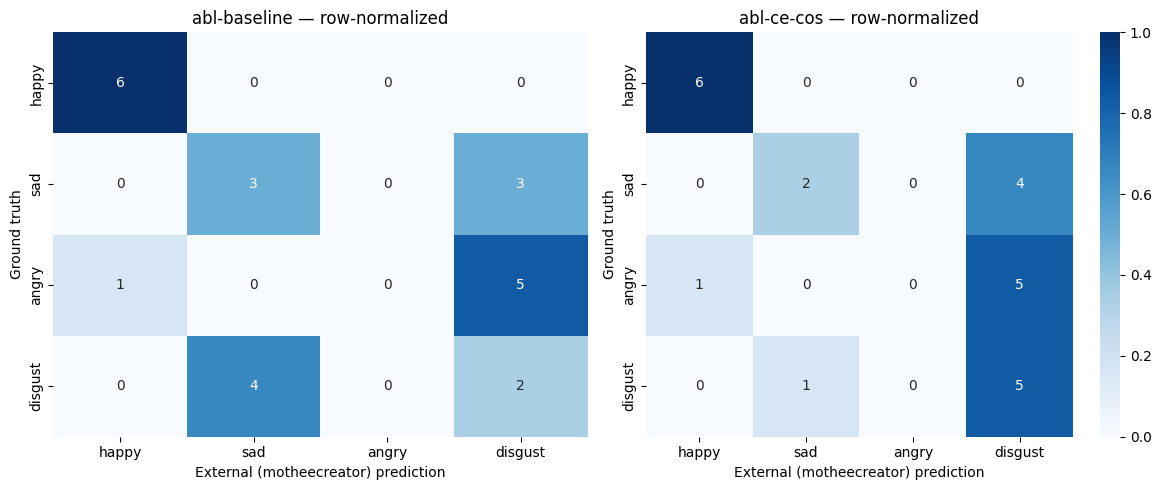


--- Rendered CM (Rajaram1996, Rajaram1996/FacialEmoRecog) ---

  abl-baseline (n=24)
         happy  sad  angry  disgust
happy        6    0      0        0
sad          1    0      2        3
angry        3    0      2        1
disgust      3    0      0        3


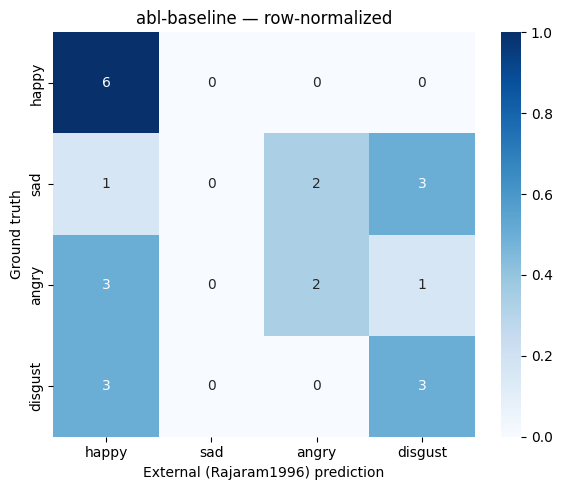

In [17]:
# Confusion matrices per external (rendered videos)
import matplotlib.pyplot as _plt
import seaborn as _sns
from sklearn.metrics import confusion_matrix

for ext_name in EXTERNALS:
    sdf = summary_per_ext_render.get(ext_name, pd.DataFrame())
    if len(sdf) == 0:
        continue
    best_cname = sdf.iloc[0]["config"]

    cm_pairs = []
    if baseline_cfg_name in per_model_external and best_cname != baseline_cfg_name:
        cm_pairs.append((baseline_cfg_name, per_model_external[baseline_cfg_name][ext_name]))
    cm_pairs.append((best_cname, per_model_external[best_cname][ext_name]))

    print(f"\n--- Rendered CM ({ext_name}, {EXTERNALS[ext_name]['model_id']}) ---")
    for title, dfm in cm_pairs:
        if len(dfm) == 0:
            continue
        cm = confusion_matrix(dfm["emotion_true"], dfm["ext_pred"], labels=list(range(len(EMOTIONS))))
        print(f"\n  {title} (n={len(dfm)})")
        print(pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS).to_string())

    n_pairs = len([p for p in cm_pairs if len(p[1]) > 0])
    if n_pairs == 0:
        continue
    fig_cm, axes_cm = _plt.subplots(1, n_pairs, figsize=(6 * n_pairs, 5), squeeze=False)
    col = 0
    for title, dfm in cm_pairs:
        if len(dfm) == 0:
            continue
        cm = confusion_matrix(dfm["emotion_true"], dfm["ext_pred"], labels=list(range(len(EMOTIONS))))
        cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        ax = axes_cm[0, col]
        _sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", vmin=0, vmax=1,
                     xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax,
                     cbar=(col == n_pairs - 1))
        ax.set_xlabel(f"External ({ext_name}) prediction")
        ax.set_ylabel("Ground truth")
        ax.set_title(f"{title} — row-normalized")
        col += 1
    _plt.tight_layout()
    _plt.show()


## Control: external classifiers on REAL RAVDESS test frames

This is the domain-shift baseline that explains why **baseline** generated
videos already give low external F1 (e.g. dima806 ≈ 0.22, trpakov ≈ 0.38
in cell 15).

We run `dima806` and `trpakov` directly on the real, ungenerated RAVDESS
test frames — no Wav2Lip, no SadTalker, no fine-tuning. If the external
F1 here is similar to the F1 on generated videos, the limitation is the
**external classifier's domain shift** (FER training data differs from
RAVDESS studio recordings), not the quality of generation. This is the
key control for the reviewer question: *why even baseline gives bad
results on external encoders?*

Compare with `04b_encoder_ceiling.ipynb` cell 6, which reported video F1 =
0.876 on the same real test split using the in-domain TimeSformer trained
in 02. The gap quantifies the domain shift exactly.


In [18]:
# Control eval: dima806 + trpakov on REAL RAVDESS test frames
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

real_per_ext = {}
for ext_name in EXTERNALS:
    rows = []
    ext = EXTERNALS[ext_name]
    tgt_indices = [ext["target_ids"][e] for e in EMOTIONS]
    for s in tqdm(test_ds.samples, desc=f"real test [{ext_name}]"):
        sid = s["sample_id"]
        gt_label = REMAP[s["emotion_idx"]]
        frames = np.load(s["frames_path"])  # (T, H, W, 3) uint8
        n_total = frames.shape[0]
        if n_total < 1:
            continue
        idx = np.linspace(0, n_total - 1, min(8, n_total)).round().astype(int)
        sampled = frames[idx]
        pil_frames = [Image.fromarray(f) for f in sampled]
        inputs = ext["proc"](pil_frames, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            logits = ext["model"](**inputs).logits
            probs = F.softmax(logits, dim=-1).cpu()
        mean_probs = probs.mean(dim=0)
        sample_label = int(mean_probs[tgt_indices].argmax().item())
        rows.append({"sample_id": sid, "emotion_true": gt_label,
                      "ext_pred": sample_label})
    real_per_ext[ext_name] = pd.DataFrame(rows)

# Compare REAL-frame F1 vs generated-frame F1 (from cell 15) for each external
real_summary_rows = []
for ext_name in EXTERNALS:
    df_real = real_per_ext[ext_name]
    if len(df_real) == 0:
        continue
    y = df_real["emotion_true"].to_numpy()
    p = df_real["ext_pred"].to_numpy()
    acc = accuracy_score(y, p)
    f1m = f1_score(y, p, labels=list(range(len(EMOTIONS))), average="macro", zero_division=0)
    per_f1 = f1_score(y, p, labels=list(range(len(EMOTIONS))), average=None, zero_division=0)
    real_summary_rows.append({
        "external": EXTERNALS[ext_name]["model_id"],
        "real_test_acc":      acc,
        "real_test_F1_macro": f1m,
        **{f"real_F1_{EMOTIONS[i]}": per_f1[i] for i in range(len(EMOTIONS))},
    })
    print(f"\n=== {EXTERNALS[ext_name]['model_id']} on REAL RAVDESS test (n={len(df_real)}) ===")
    print(f"  acc: {acc:.3f}  |  macro F1: {f1m:.3f}")
    for i, e in enumerate(EMOTIONS):
        print(f"    {e:>8s}  F1={per_f1[i]:.3f}")
    cm = confusion_matrix(y, p, labels=list(range(len(EMOTIONS))))
    print("  confusion (rows=true, cols=pred):")
    print(pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS).to_string())

real_summary_df = pd.DataFrame(real_summary_rows)
real_summary_df.to_csv(OUT_DIR / "external_on_real_test.csv", index=False)

# Compare to internal TimeSformer ceiling (04b cell 6: video macro F1 = 0.876).
print("\n=== Domain-shift summary ===")
print("Internal TimeSformer (4emo) on REAL test:           macro F1 ≈ 0.876 (from 04b)")
for r in real_summary_rows:
    print(f"External {r['external']:50s} on REAL test:  macro F1 = {r['real_test_F1_macro']:.3f}")
print("\nInterpretation: the gap between internal ceiling (~0.88) and external")
print("F1 on real frames quantifies how much external classifiers under-recognize")
print("emotions in RAVDESS-style data. This domain shift is the floor for any")
print("generation method evaluated by these externals — even a perfect generator")
print("would not exceed external F1 on real frames.")


real test [Rajaram1996]: 100%|██████████| 96/96 [00:02<00:00, 36.91it/s]


=== motheecreator/vit-Facial-Expression-Recognition on REAL RAVDESS test (n=96) ===
  acc: 0.542  |  macro F1: 0.476
       happy  F1=0.738
         sad  F1=0.133
       angry  F1=0.410
     disgust  F1=0.621
  confusion (rows=true, cols=pred):
         happy  sad  angry  disgust
happy       24    0      0        0
sad          7    2      7        8
angry        8    0      8        8
disgust      2    4      0       18

=== Rajaram1996/FacialEmoRecog on REAL RAVDESS test (n=96) ===
  acc: 0.490  |  macro F1: 0.462
       happy  F1=0.744
         sad  F1=0.250
       angry  F1=0.263
     disgust  F1=0.592
  confusion (rows=true, cols=pred):
         happy  sad  angry  disgust
happy       16    0      0        8
sad          0    5      8       11
angry        3    9      5        7
disgust      0    2      1       21

=== Domain-shift summary ===
Internal TimeSformer (4emo) on REAL test:           macro F1 ≈ 0.876 (from 04b)
External motheecreator/vit-Facial-Expression-Recognition   